# Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import pydotplus
from sklearn import preprocessing
%config InlineBackend.figure_format='retina'
sns.set() # Revert to matplotlib defaults
plt.rcParams['figure.figsize'] = (8, 8)
plt.rcParams['axes.labelpad'] = 10
sns.set_style("darkgrid")

#Introduction

## Classification Supervised Learning

Classification is a type of supervised machine learning where algorithms learn from the data to predict an outcome or event in the future. For example:

A bank may have a customer dataset containing credit history, loans, investment details, etc. and they may want to know if any customer will default. In the historical data, we will have Features and Target.

Features will be attributes of a customer such as credit history, loans, investments, etc.
Target will represent whether a particular customer has defaulted in the past (normally represented by 1 or 0 / True or False / Yes or No.)

Classification algorithms are used for predicting discrete outcomes, if the outcome can take two possible values such as True or False, Default or No Default, Yes or No, it is known as **Binary Classification**. e.g. Classify emails as either "Spam" (1) or "Not Spam" (0).

When the outcome contains more than two possible values, it is known as **Multiclass Classification**. e.g. Classifying images of fruits into categories such as "apple," "banana," "orange," or "pear"

If we classify instances into multiple categories or labels simultaneously, it is known as **Multilabel Classification**. e.g. Classifying a document into multiple topics (e.g., politics, finance, education).

Finally, Predicting multiple outputs, where each output represents a distinct target variable is called **Multioutput Classification**. e.g.Predicting multiple medical conditions simultaneously based on patient symptoms and test results. For instance, diagnosing heart disease risk (low/medium/high) and diabetes status (yes/no) from a single set of patient data

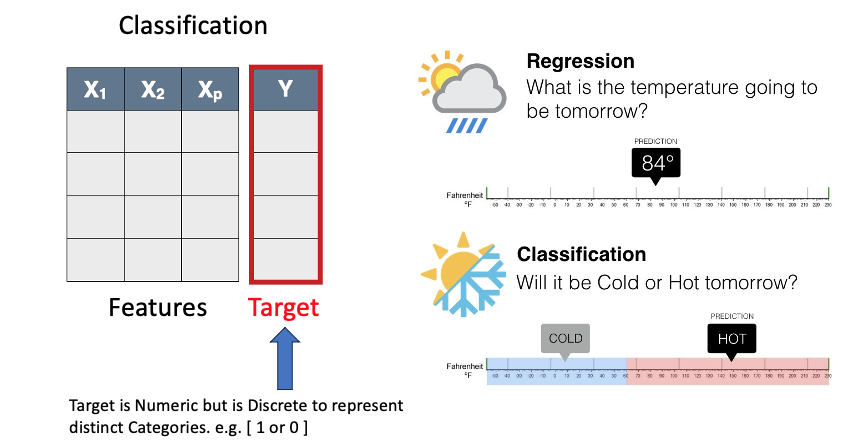

Very often when you start learning about classification problems in Machine Learning, you start with binary classification or where there are only two possible outcomes, such as spam or not spam, fraud or not fraud, and so on. We have Multi-class and multi-label classification beyond that. Let's start by explaining each one. Here is a Simple way to Understand the differences





![image.png](https://miro.medium.com/v2/resize:fit:1111/1*5G7bLP5BgQWJjFuyjiEf6A.png)


| Feature | **Multi-class Classification** | **Multi-label Classification** | **Multi-output Classification** |
| :-- | :-- | :-- | :-- |
| **Definition** | Each instance belongs to exactly one class out of multiple mutually exclusive classes. | Each instance can belong to multiple classes simultaneously, with no exclusivity. | Each instance has multiple outputs, where each output corresponds to a separate classification or regression task. |
| **Output Structure** | A single label (categorical) is assigned to each instance (e.g., one-hot encoding). | A binary vector is assigned, where each element indicates the presence or absence of a specific label. | A vector with multiple outputs, where each element corresponds to a distinct task (classification or regression). |
| **Label Semantics** | Labels are mutually exclusive (e.g., "cat" vs. "dog"). | Labels are not mutually exclusive (e.g., "cat" and "outdoor"). | Outputs are independent and represent different tasks (e.g., predicting type and color of clothing). |
| **Example** | Classifying an image as either "cat," "dog," or "bird." | Tagging an image with labels like "cat," "outdoor," and "sunset." | Predicting both the type of clothing (e.g., shirt, jeans) and its color (e.g., red, blue). |

## Multi-Class Classification

Multi-Class Classification is where you have more than two categories in your target variable (y). For example, you could have small, medium, large, and xlarge, or you might have a rating system based on one to five stars. Each of these levels can be considered a class as well. The objective of this strategy is to predict a single class out of the available classes.

Check out the Scikit-Learn [Documentation](https://scikit-learn.org/stable/modules/multiclass.html#ovr-classification) for more information.

### **Multi-Class Strategies**

###**1. The One-vs-Rest or (OVR), also called One-vs-All (OVA) strategy**:
This fits a single classifier for each class that is fitted against all other classes (Commonly used by logistic regression). OVR is essentially is splitting the multi-class problem into a set of binary classification problems.

### How OvR Outputs One Class

1. **Training Process**: For a dataset with $N $ classes, OvR trains $N $ binary classifiers. Each classifier is trained to distinguish one class from all others.
2. **Prediction Process**: When making predictions, each of the $N $ classifiers outputs a probability or confidence score indicating how likely the input belongs to the class it represents.
3. **Final Output**: The class with the highest probability or confidence score is selected as the final prediction. This means that only one class is output for each input instance, even though multiple classifiers are involved

### Example

Consider a multiclass classification problem with three classes: **red**, **blue**, and **green**.

- **Classifier 1**: Trained to distinguish **red** from **blue** and **green**.
- **Classifier 2**: Trained to distinguish **blue** from **red** and **green**.
- **Classifier 3**: Trained to distinguish **green** from **red** and **blue**.

When predicting a new instance, each classifier outputs a score. The class with the highest score is chosen as the final output, ensuring that only one class is assigned to each instance.

OvR requires training a separate binary classifier for each class. For a dataset with $N $  classes, this means $N $  models need to be trained. As $N $ increases, the computational cost and memory requirements grow linearly, which can be challenging for large datasets.

### **2. The One-vs-One (OVO) strategy:**

This fits a single classifier for each pair of classes (Commonly used by SVM). Thus performing **Pairwise Comparisons**. OvO involves training a separate binary classifier for each pair of classes in the dataset. For a dataset with N classes, this results in $\frac{N(N-1)}{2}$binary classifiers.

### How OvO Works

1. **Training Process**: Each binary classifier is trained to distinguish between two classes. For example, if you have classes **red**, **blue**, and **green**, you would train classifiers for **red vs. blue**, **red vs. green**, and **blue vs. green**.
2. **Prediction Process**: When making predictions, each of the $\frac{N(N-1)}{2}$ classifiers outputs a prediction. The class that receives the most votes across all classifiers is selected as the final prediction.
3. **Final Output**: Like **One-vs-Rest (OvR)**, OvO outputs a single class prediction for each input instance.

### Example

Consider a multiclass classification problem with three classes: **red**, **blue**, and **green**.

- **Classifier 1**: Trained to distinguish **red** from **blue**.
- **Classifier 2**: Trained to distinguish **red** from **green**.
- **Classifier 3**: Trained to distinguish **blue** from **green**.

When predicting a new instance, each classifier outputs a prediction. The class that wins the most pairwise comparisons is chosen as the final output.

While the compute complexity is higher than the OVR strategy, it can be advantageous when you have a large number of classes because each of the classifiers is fit on a smaller subset of the data, where the OVR strategy is fit on the entire dataset for each classifier.

Here's a detailed comparison of **One-vs-Rest (OvR)** and **One-vs-One (OvO)** strategies in a table format:


| Feature | One-vs-Rest (OvR) | One-vs-One (OvO) |
| :-- | :-- | :-- |
| **Number of Models** | $N $ models for $N $ classes | $\frac{N(N-1)}{2}$ for $N $ classes |
| **Training Data** | Each model trained on the entire dataset, with one class as positive and all others as negative | Each model trained on a subset of the data, comparing two classes at a time |
| **Computational Cost** | Less expensive due to fewer models | More expensive due to more models |
| **Class Balance** | Can suffer from class imbalance| Less prone to class imbalance, as each model compares two classes |
| **Use Case** | Suitable for most multiclass problems, especially when computational resources are limited | Beneficial when detailed pairwise comparisons are valuable, such as in datasets with complex class relationships |
| **Prediction Method** | Predicts the class with the highest confidence score across all models | Predicts the class that wins the most pairwise comparisons |
| **Scalability** | Can be challenging for very large numbers of classes due to model complexity | More challenging for large numbers of classes due to the increased number of models required |

[Click Here](https://scikit-learn.org/stable/auto_examples/multiclass/plot_multiclass_overview.html#sphx-glr-auto-examples-multiclass-plot-multiclass-overview-py) To see a detailed comparison of Multiclass Classification Strategies where we see that **once the hyperparameters are optimized, all multiclass strategies have similar performance**.

## Multi label Classification
Here you have more than two categories available as well, but instead of choosing only a single class, the objective of this strategy is to predict multiple classes when applicable.

Multilabel classification is a machine learning task where each instance can be assigned multiple non-exclusive labels. Unlike multiclass classification, where an instance belongs to one class, multilabel classification allows for multiple labels per instance. For example, in text classification, an article might be labeled as both politics and economy.

This approach is useful in scenarios where data can belong to multiple categories simultaneously, such as image tagging or document categorization.

In Scikit-Learn, multilabel classification can be approached using:

###**1. MultiOutputClassifier (also known as Binary Relevance)**

- **Description**: This meta-estimator fits a separate classifier for each output variable. It treats each label as an independent output variable, which makes it suitable for multilabel classification tasks.
- **How It Works**:
    - **Training**: For a dataset with multiple labels, it trains a separate model for each label. Each model predicts whether a particular label is present or not.
    - **Prediction**: When predicting, it outputs a binary vector where each element corresponds to the presence (1) or absence (0) of a label.
- **Advantages**:
    - Easy to implement and interpret.
    - Fast training time since each model is trained independently.
- **Disadvantages**:
    - Does not account for correlations between labels.


### Example

Consider a text classification task where articles can be labeled as **politics**, **economy**, or **sports**. Using **MultiOutputClassifier**, you would train three separate models:

- Model 1: Predicts whether an article is about **politics**.
- Model 2: Predicts whether an article is about **economy**.
- Model 3: Predicts whether an article is about **sports**.

Each model outputs a binary prediction (0 or 1), resulting in a binary vector indicating which labels apply to the article.

### **2. ClassifierChain**

- **Description**: This meta-estimator trains a chain of classifiers. Each classifier in the chain is trained on the features and the predictions of the previous classifier.
- **How It Works**:
    - **Training**: The first classifier is trained on the input features. Each subsequent classifier is trained on both the input features and the predictions of the previous classifiers.
    - **Prediction**: When predicting, each classifier outputs a prediction based on the input features and previous predictions. The final output is a binary vector indicating the presence or absence of each label.
- **Advantages**:
    - Can exploit correlations between labels by using previous predictions as features.
    - Potentially better performance when labels are highly correlated.
- **Disadvantages**:
    - More complex to implement and interpret.
    - Training can be slower due to the sequential nature of the chain.


### Example

Using the same text classification task as above, **ClassifierChain** would work as follows:

1. **First Classifier**: Trained to predict whether an article is about **politics**.
2. **Second Classifier**: Trained on the input features plus the prediction from the first classifier to predict whether an article is about **economy**.
3. **Third Classifier**: Trained on the input features plus the predictions from the first two classifiers to predict whether an article is about **sports**.

This approach allows the model to consider the relationships between labels, potentially improving performance if there are strong correlations between them.

### Comparison

| Feature | MultiOutputClassifier | ClassifierChain |
| :-- | :-- | :-- |
| **Label Dependencies** | Does not account for dependencies between labels | Accounts for dependencies by using previous predictions as features |
| **Complexity** | Simpler to implement and interpret | More complex due to chaining |
| **Performance** | Generally faster training time | Can offer better performance when labels are correlated |


## Training classification models   

On the modeling side, you should avoid overfitting, which happens when the model fits too well on the training data so that it fails to generalize to testing samples.

Similarly, you should also try to avoid underfitting, where the model is not able
to capture the interesting patterns that would yield higher accuracy.

The solution to this is trying many different types of models and being careful to follow best practices.



---

Recall the two types of supervised machine learning: regression and classification.
In regression, we predict a numerical target variable.The other type of supervised machine learning is classification and the goal of which is to predict the class of a record using the available metrics.

However classification depends on how well you can model a decision boundary, which can be in the simplest case linear or non-linear

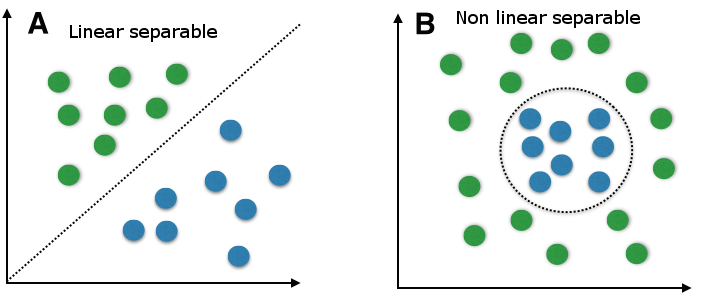


---

Here we see example of Linearly seperable Data

<Axes: xlabel='X1', ylabel='X2'>

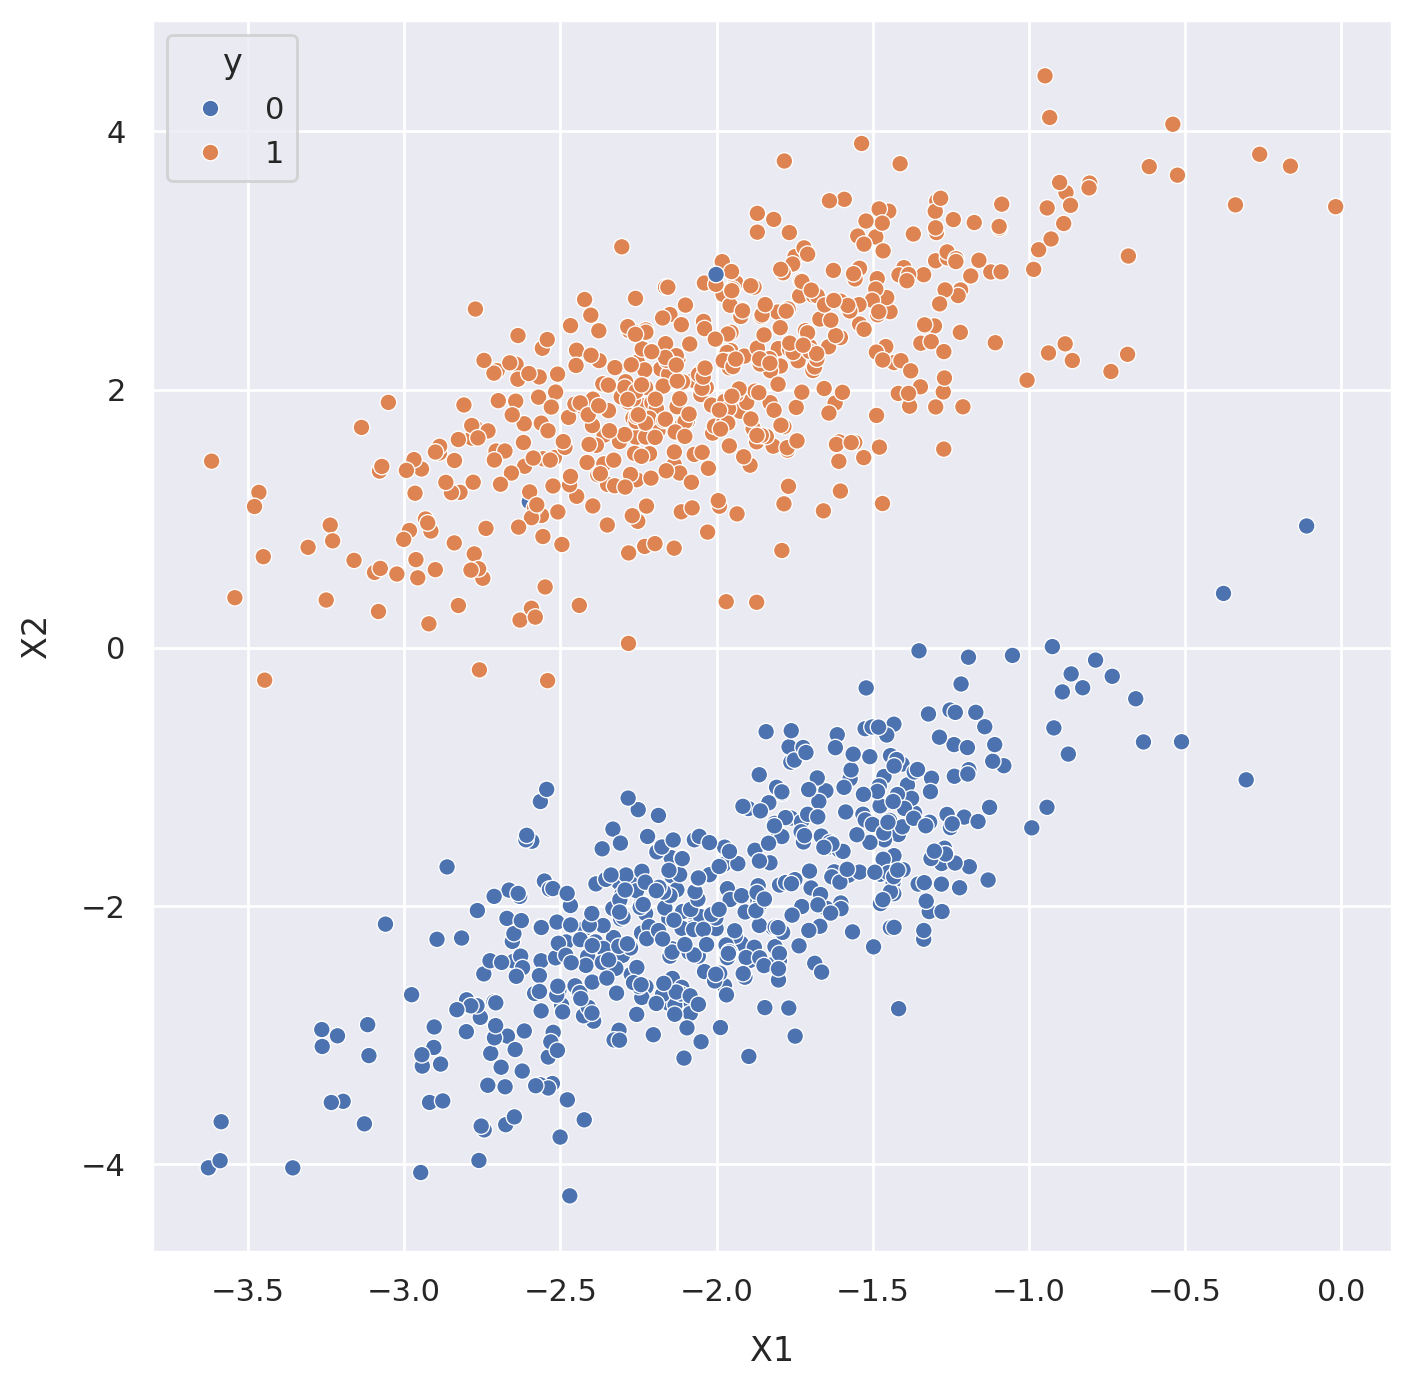

In [ ]:
from sklearn.datasets import make_classification
X,y = make_classification(n_samples=1000, n_features=2, n_informative=2,n_redundant=0, n_repeated=0, n_classes=2, n_clusters_per_class=1, class_sep=2,random_state=12)
df = pd.DataFrame(X, columns=["X1","X2"])
df['y']=pd.DataFrame(y,columns=["y"])
# Do a scatter plot of the data
sns.scatterplot(x='X1', y='X2', data=df, hue='y')

Non-Linearly seperable Data

<Axes: xlabel='X1', ylabel='X2'>

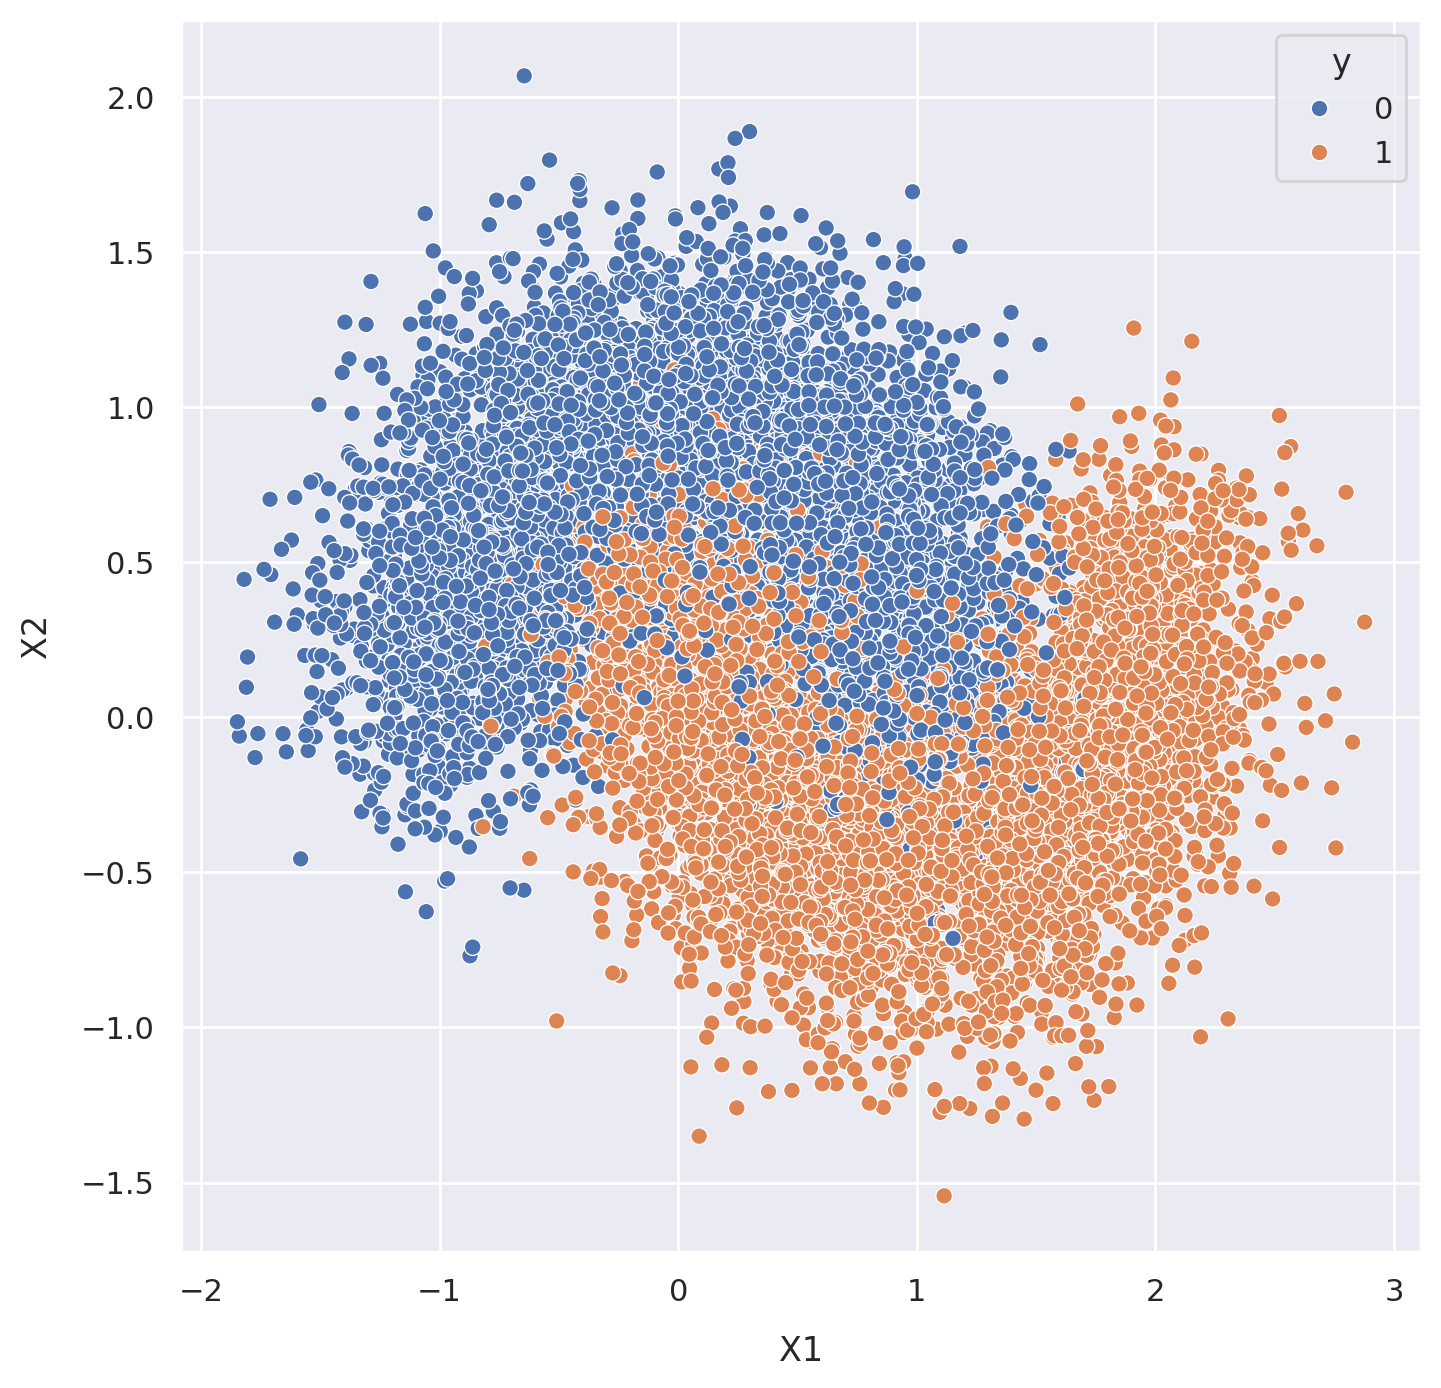

In [ ]:
from sklearn.datasets import make_moons
# Construct non-linear dataset 2
X, y = make_moons(n_samples=10000,noise=0.3, random_state=0)
df = pd.DataFrame(X, columns=["X1","X2"])
df['y']=pd.DataFrame(y,columns=["y"])
# Do a scatter plot of the data
sns.scatterplot(x='X1', y='X2', data=df, hue='y')

A more realistic representation from Real Dataset

<Axes: xlabel='satisfaction_level', ylabel='last_evaluation'>

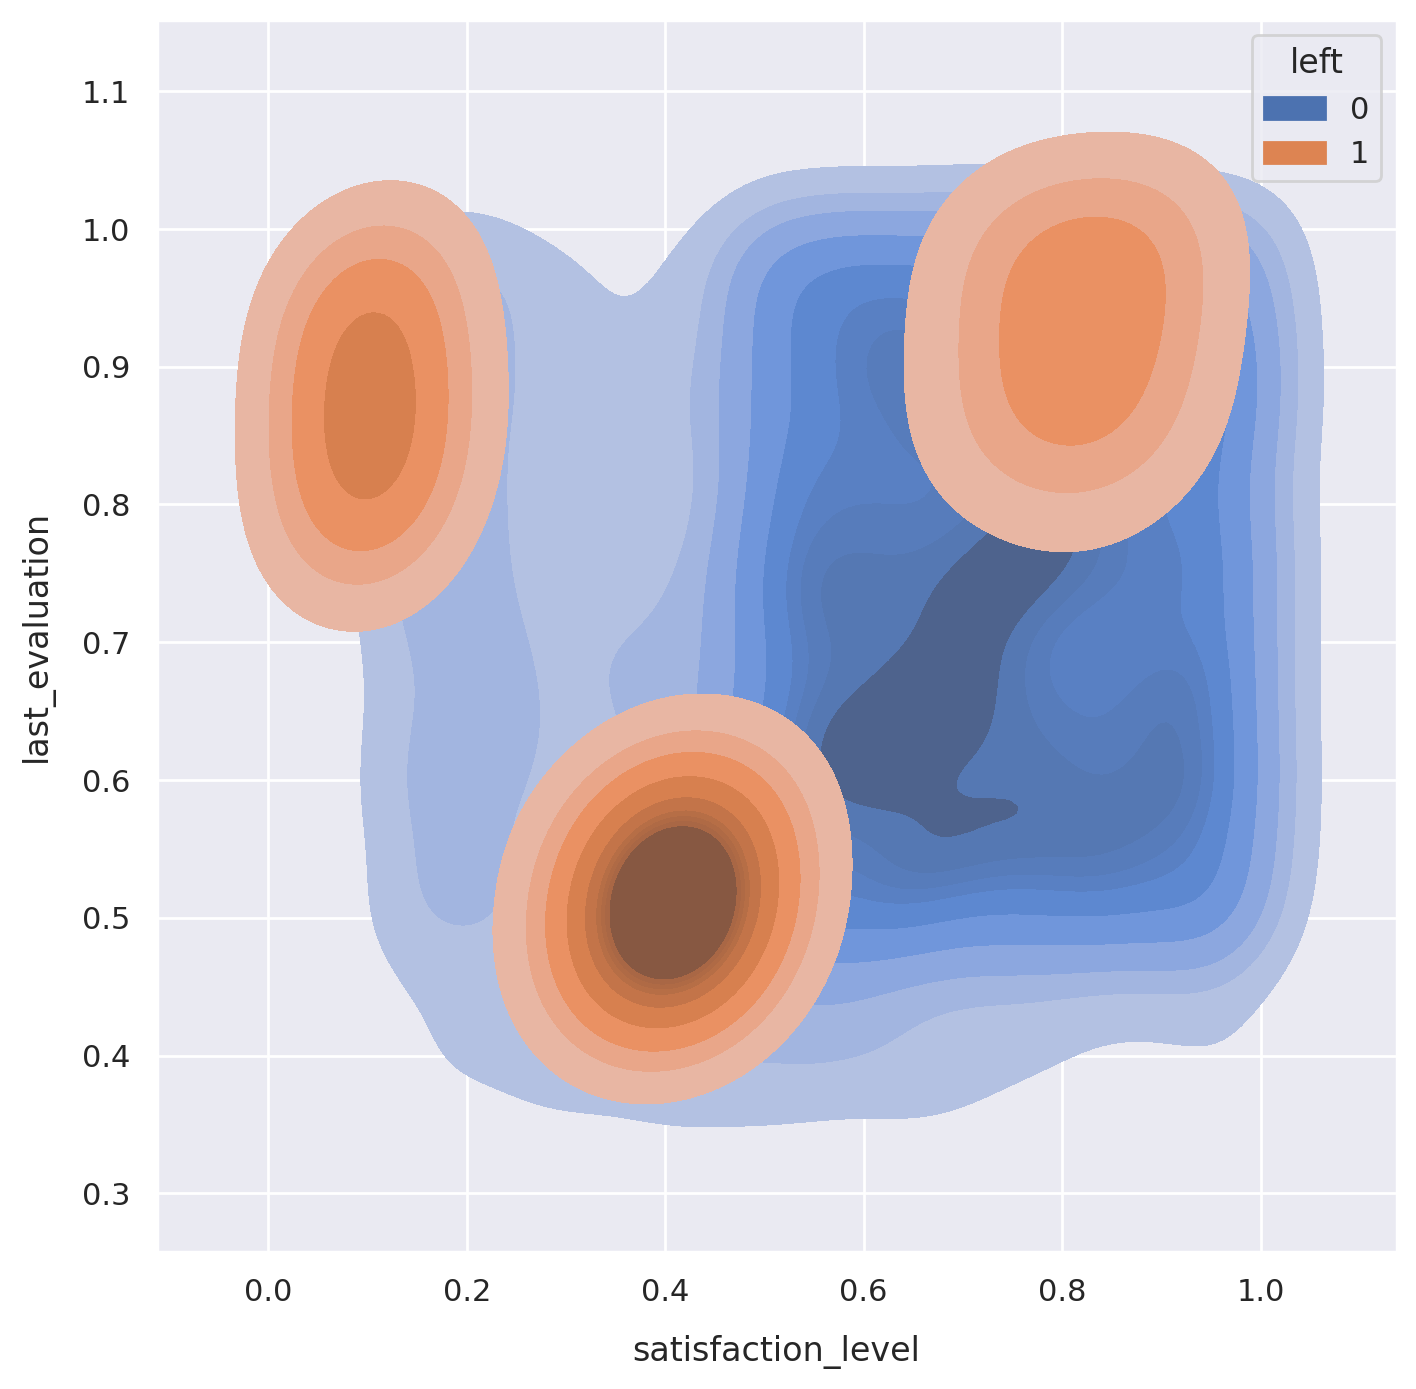

In [ ]:
# Load the processed data
# first upload and then load
#HR Analytics Dataset
hr_df = pd.read_csv('https://raw.githubusercontent.com/PacktWorkshops/The-Applied-Data-Science-Workshop/refs/heads/master/data/hr-analytics/hr_data_processed.csv')
fig, ax = plt.subplots()
sns.kdeplot(x='satisfaction_level',y='last_evaluation',data=hr_df, hue="left", fill=True)
#Now, you can see how the patterns are related to the target variable.


Feel free to design your own classifiers for these two datasets. (Home Work)

# Multiclass Classification with the Iris Dataset


## Dataset


The data set contains 3 classes of 50 instances each, where each class refers to a type of iris plant.  One class is linearly separable from the other 2; the latter are not linearly separable from each other.

Predicted attribute: class of iris plant.

![Image in a markdown cell](https://www.researchgate.net/publication/367220930/figure/fig1/AS:11431281113694842@1674035105600/Three-species-of-IRIS-flower.jpg)

This data set consists of the physical parameters of three species of flower — Versicolor, Setosa and Virginica. The numeric parameters which the dataset contains are Sepal width, Sepal length, Petal width and Petal length. In this data we will be predicting the classes of the flowers based on these parameters.The data consists of continuous numeric values which describe the dimensions of the respective features. We will be training the model based on these features.


https://archive.ics.uci.edu/dataset/53/iris

In [ ]:
data = pd.read_csv('https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv')
data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


![image.png](https://miro.medium.com/v2/resize:fit:875/1*H2UmG5L1I5bzFCW006N5Ag.png)

## Preperation/Cleaning and EDA

In [ ]:
# Let's see what's in the iris data
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
data.describe() #descriptive statistics

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
#Calculate how many flowers in each species
data.groupby('species').species.count()

,species
species,
setosa,50
versicolor,50
virginica,50


<Axes: xlabel='species', ylabel='count'>

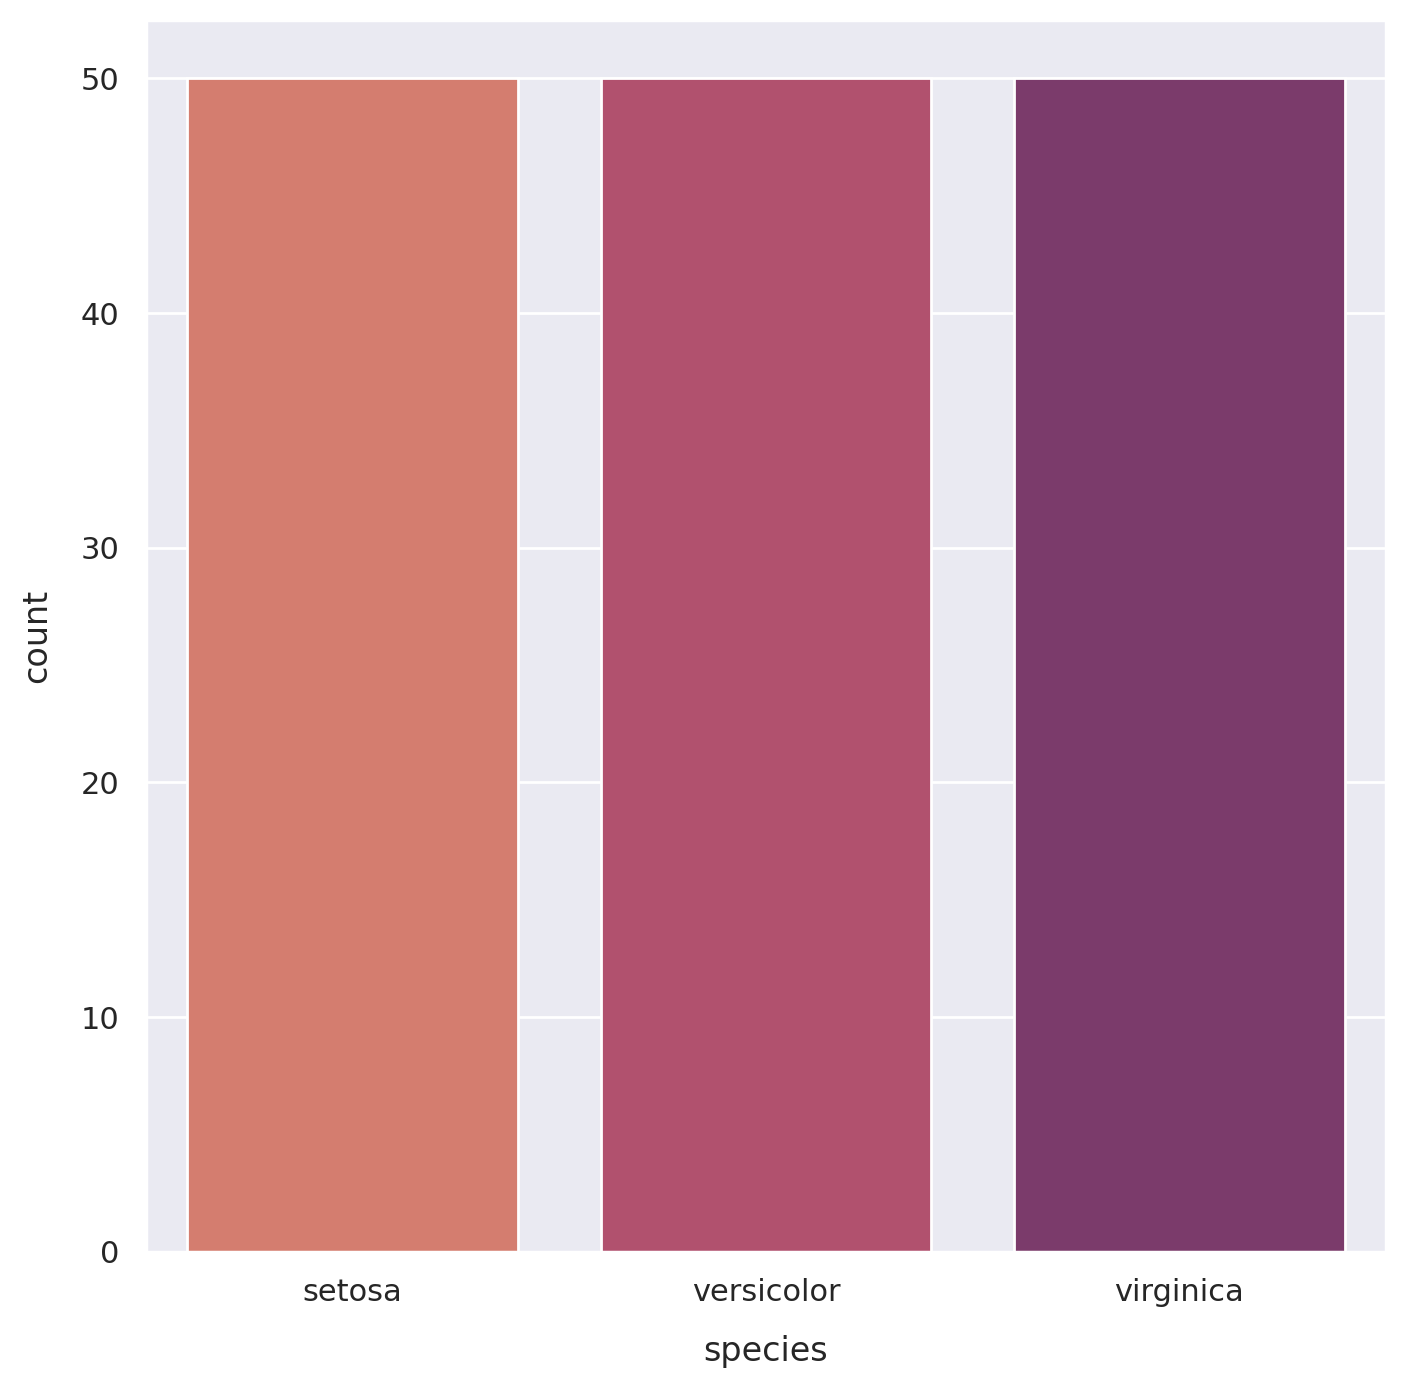

In [ ]:
sns.countplot(x='species',data=data, palette="flare", hue='species') #count plot

In [ ]:
#Calculate mean and median or others using multiple functions at once
data.groupby('species').agg(['mean', 'median','count'])  # passing a list of recognized strings

sepal_length              sepal_width              petal_length  \
                   mean median count        mean median count         mean   
species                                                                      
setosa            5.006    5.0    50       3.418    3.4    50        1.464   
versicolor        5.936    5.9    50       2.770    2.8    50        4.260   
virginica         6.588    6.5    50       2.974    3.0    50        5.552   

                        petal_width               
           median count        mean median count  
species                                           
setosa       1.50    50       0.244    0.2    50  
versicolor   4.35    50       1.326    1.3    50  
virginica    5.55    50       2.026    2.0    50

Analysing the data visually

lets plot a pair plot

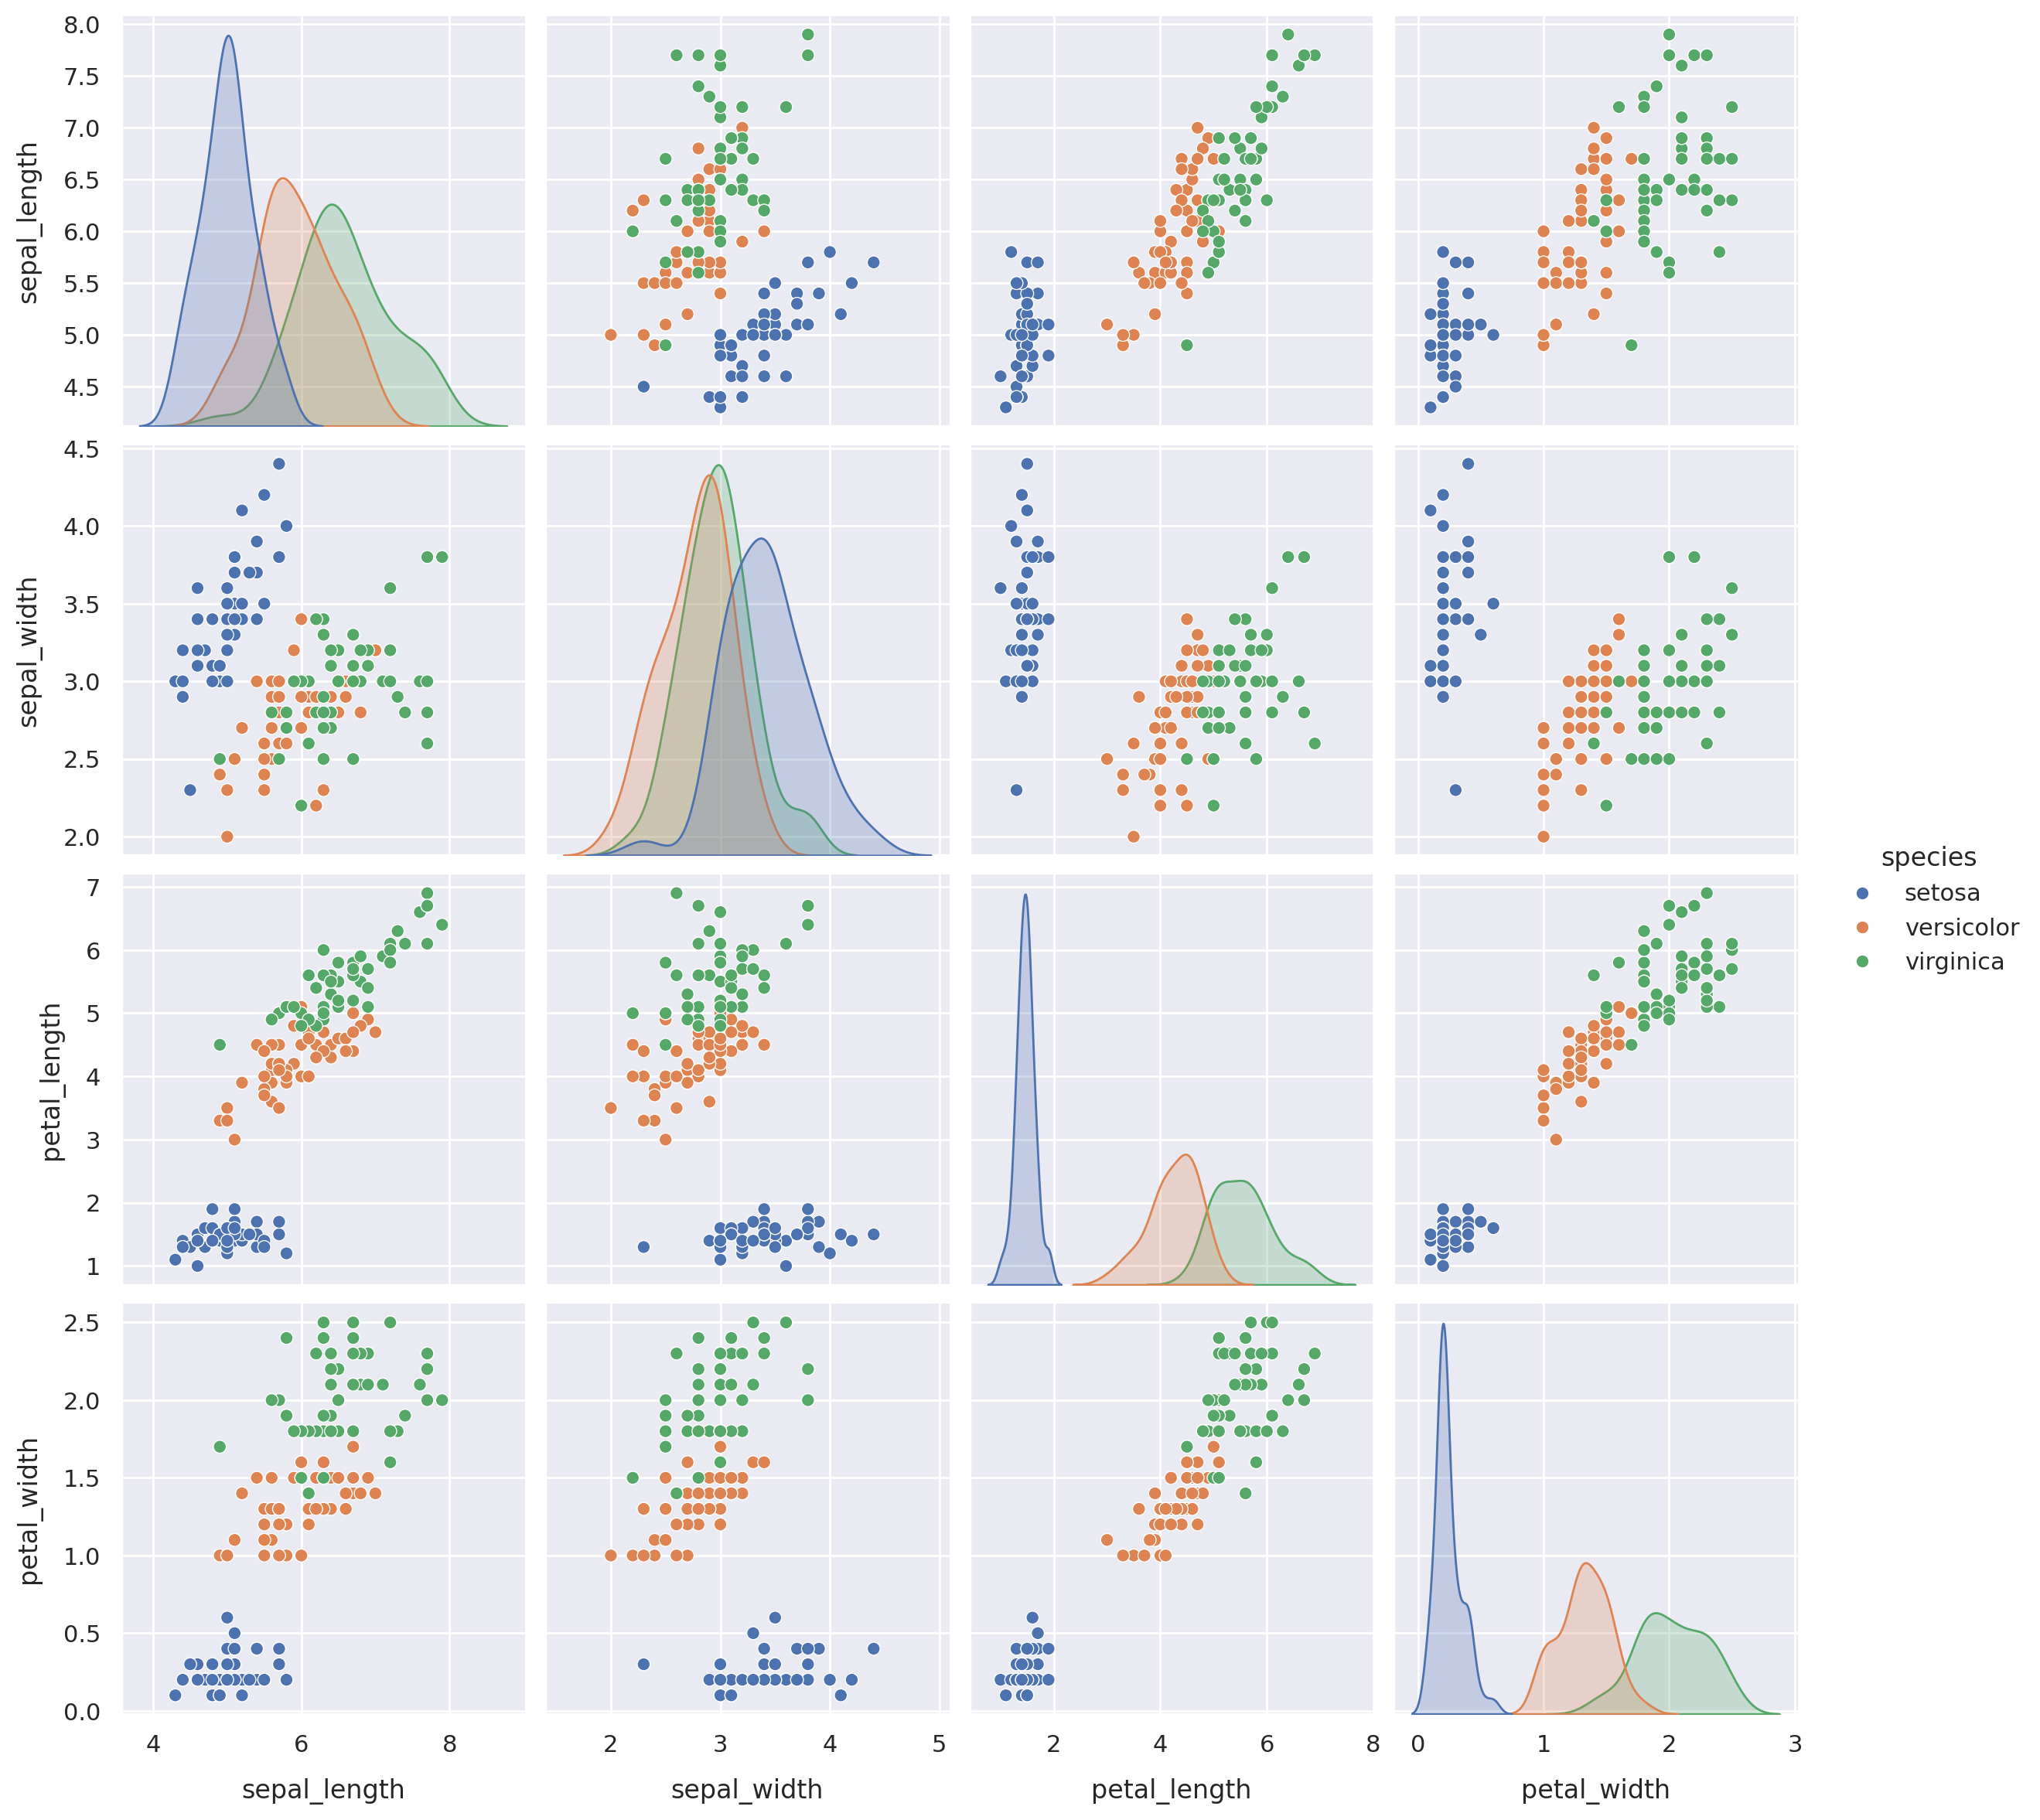

In [ ]:
sns.pairplot(data, hue="species", height=3)

**TAKE-AWAY From the KDE and pairplots, we observe that Petal length and Petal width are influencing variables for the different species**

Now for some Box plots

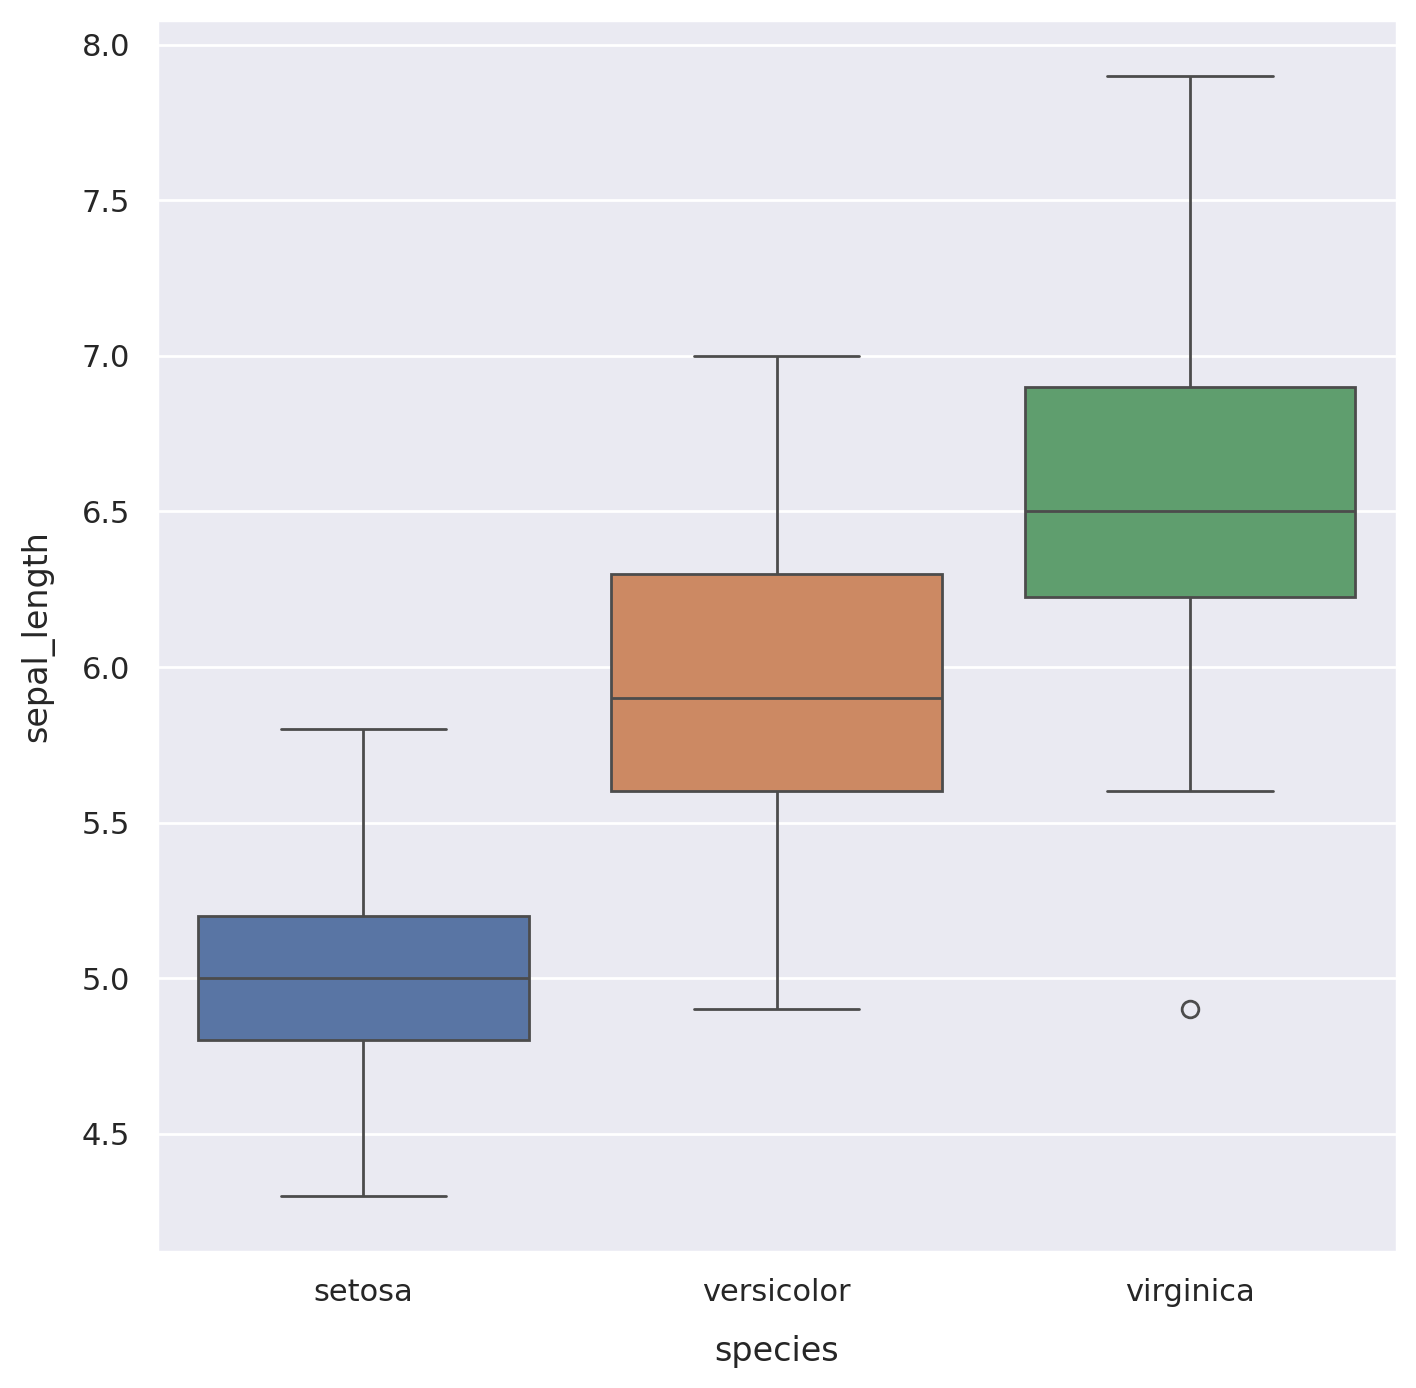

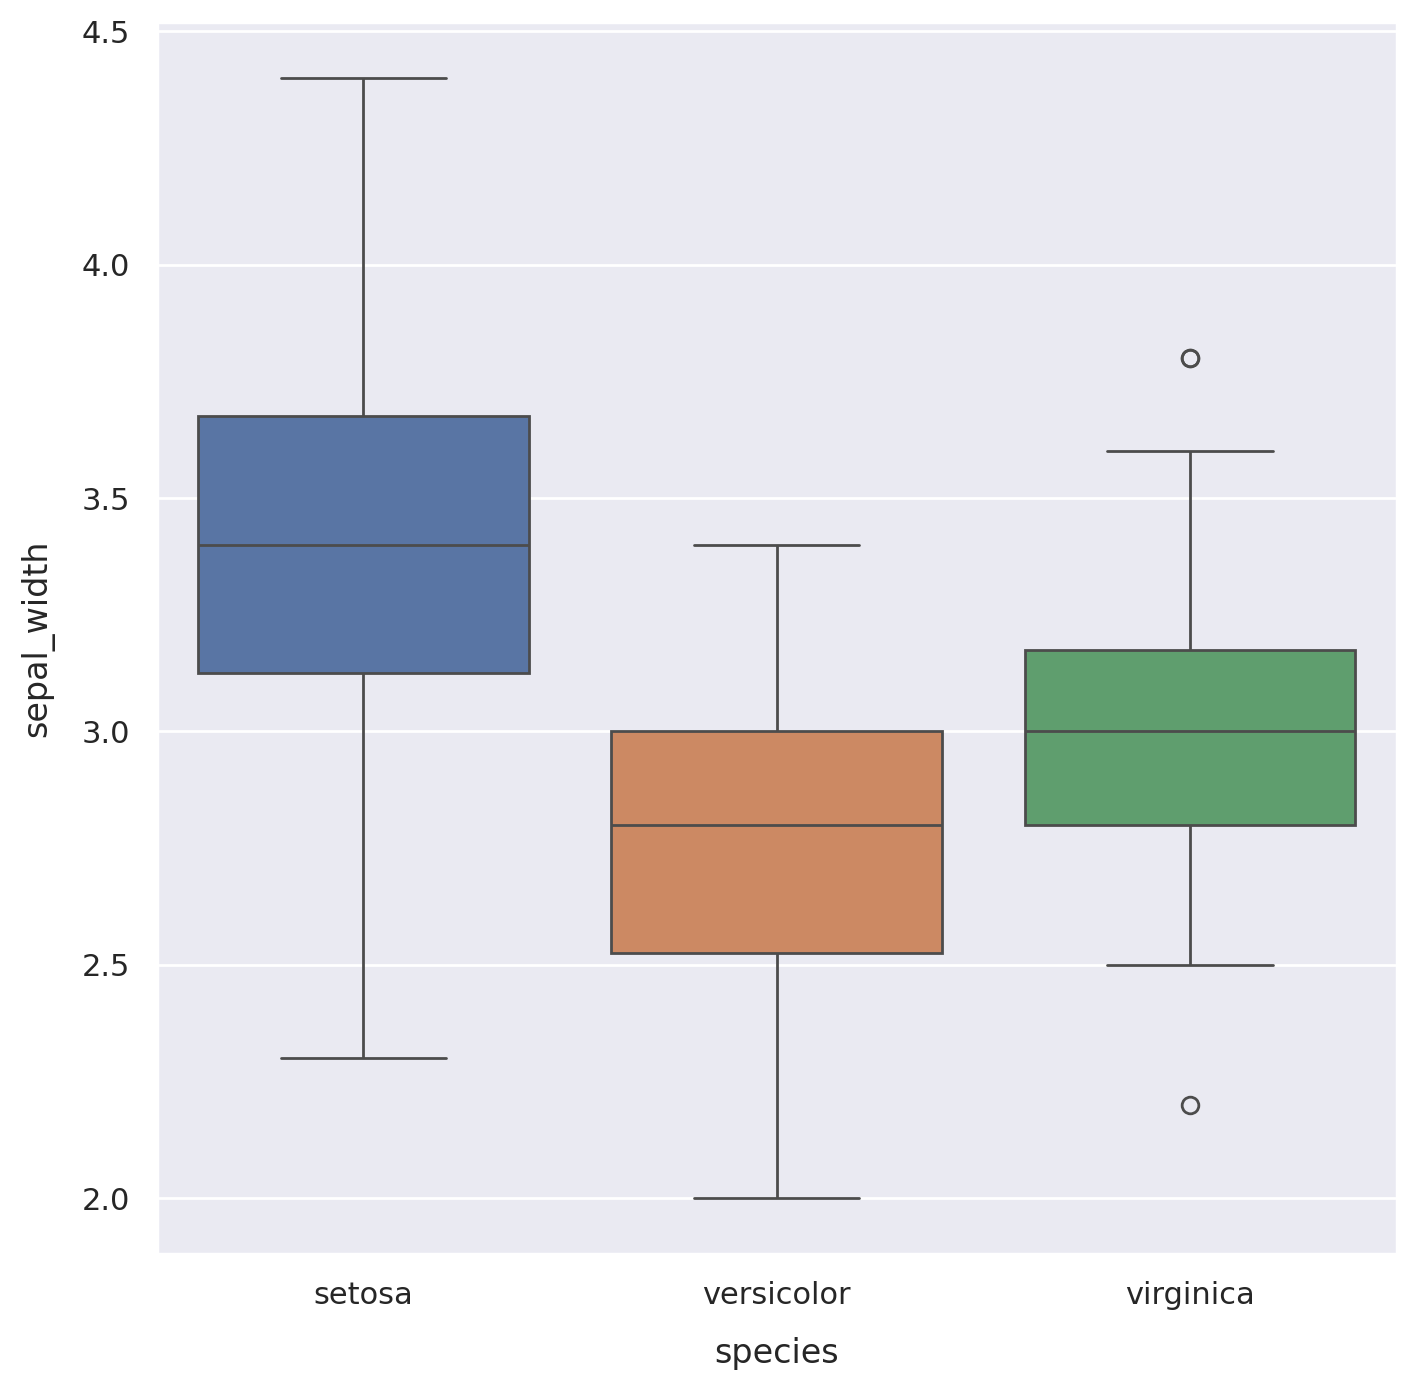

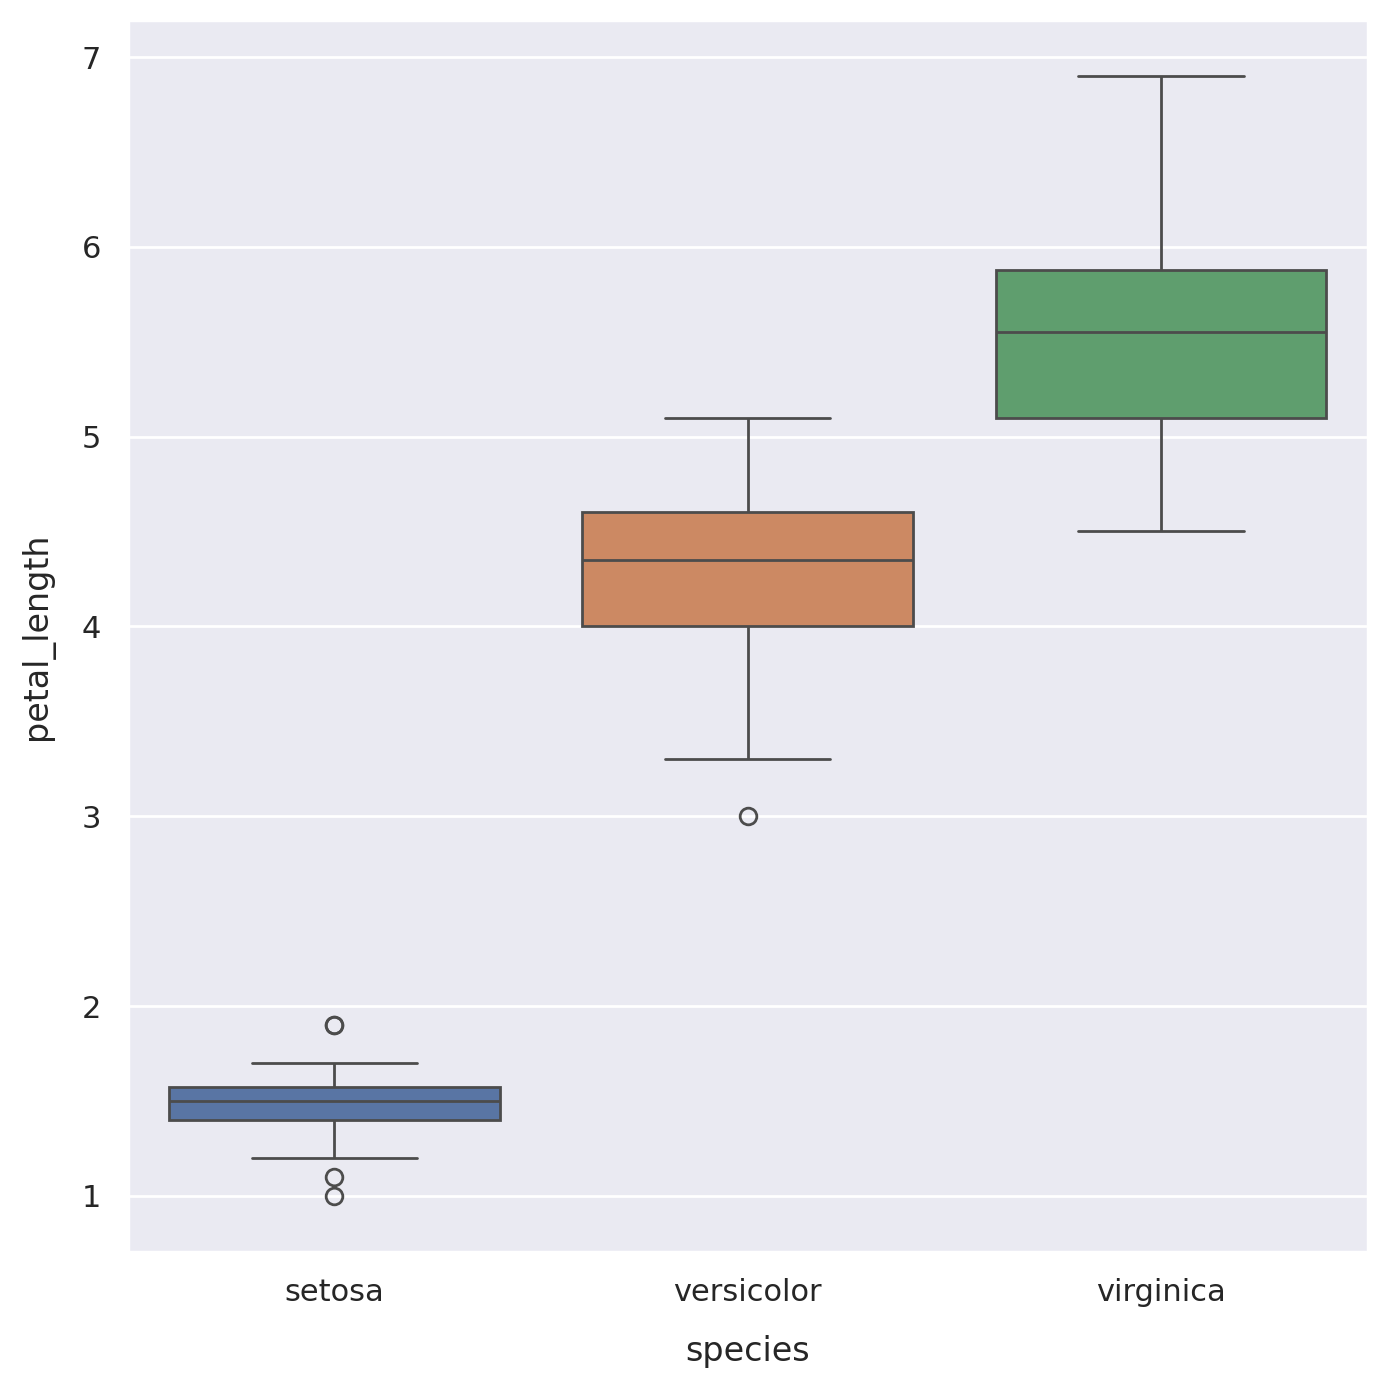

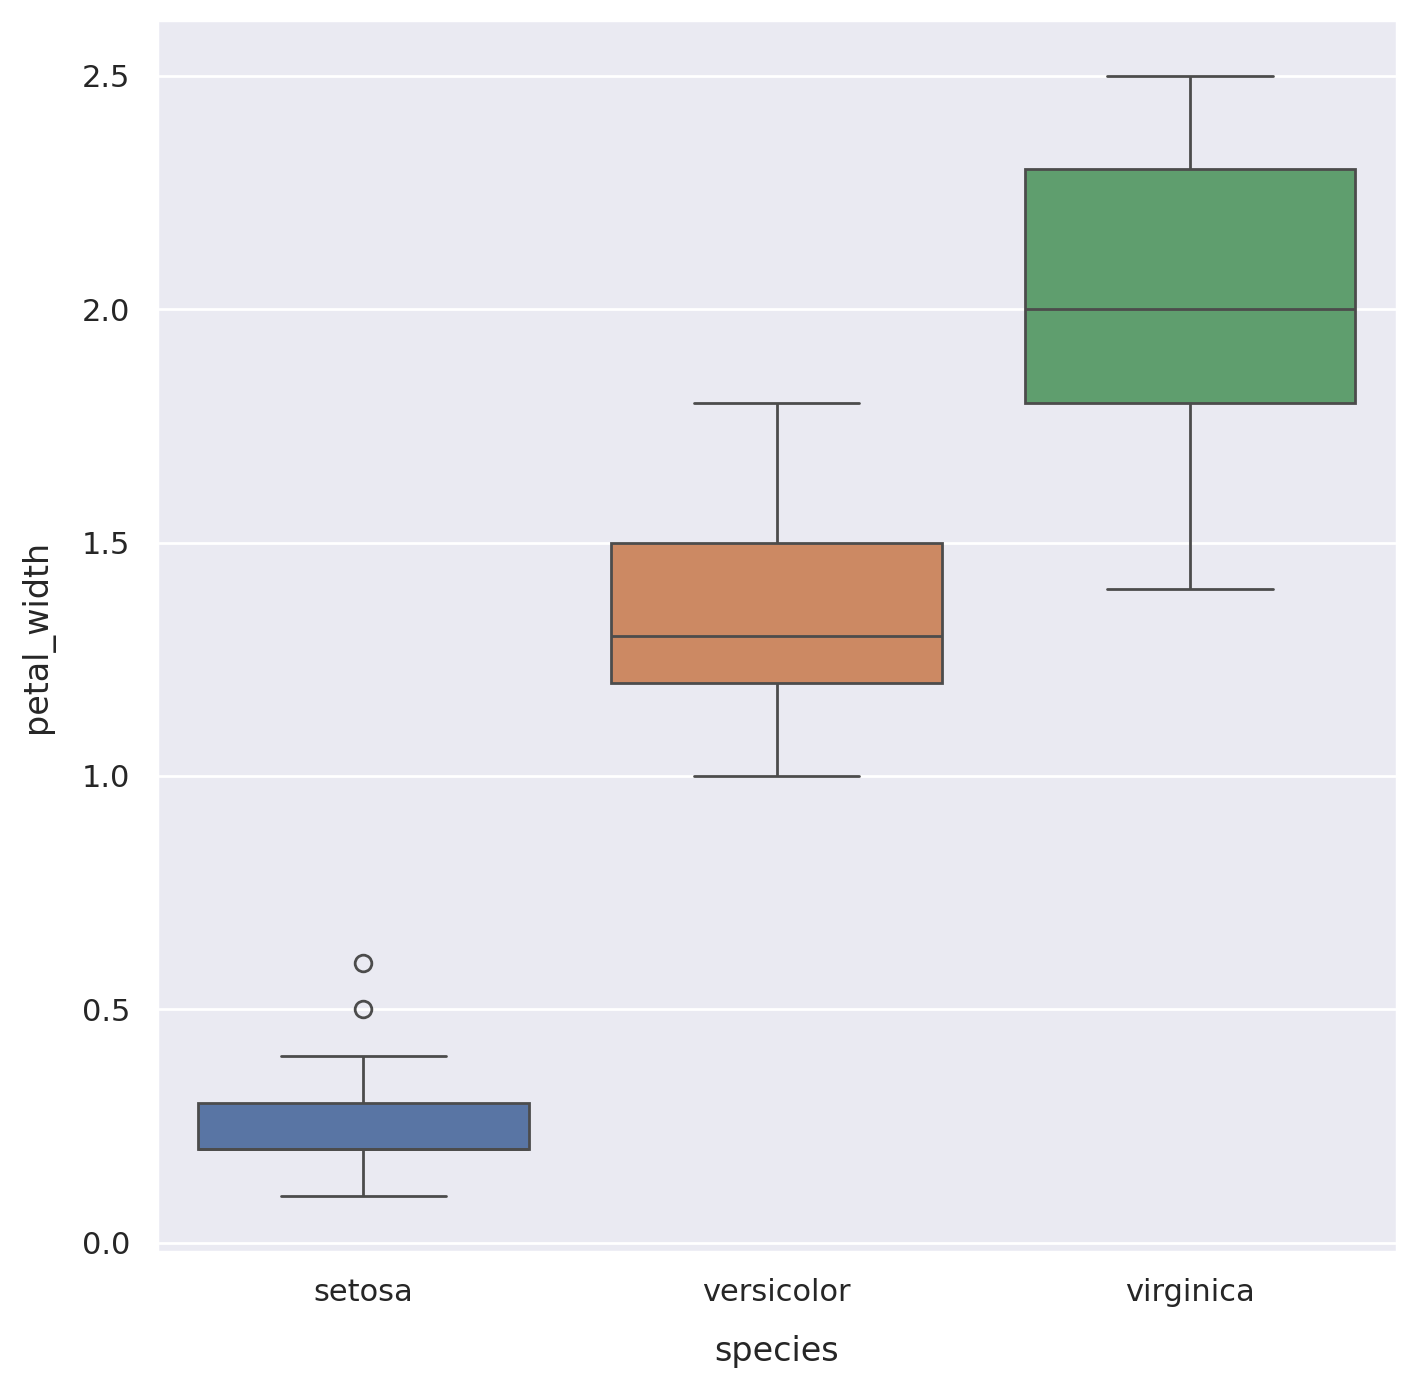

In [ ]:
for feature in data.columns[:-1]:
  sns.boxplot(x="species", y=feature, data=data, hue='species')
  plt.show()

Missing Data

In [ ]:
data.isnull().values.any() #No missing data

False

Encoding the Categorical Variable

In [ ]:
#creating instance of a label encoder
encode = LabelEncoder()

#Assigning numerical values and storing in the same name column 'species'
data.species = encode.fit_transform(data.species)

Train - Test Split

In [ ]:
target = 'species'
X = data[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = data[target]
# Splitting the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state = 99)
X_train.head()
# it shows 70% of data is split for training and 30% of the data goes to testing.
print(X_train.shape)
print(X_test.shape)

(105, 4)
(45, 4)


## Primer on Confusion Matrix

A confusion matrix is a matrix that summarizes the performance of a machine learning model on a set of test data. It is a means of displaying the number of accurate and inaccurate instances based on the model’s predictions. It is often used to measure the performance of classification models, which aim to predict a categorical label for each input instance.

The matrix displays the number of instances produced by the model on the test data.

* True positives (TP): occur when the model accurately predicts a positive data point.
* True negatives (TN): occur when the model accurately predicts a negative data point.
* False positives (FP): occur when the model predicts a positive data point incorrectly.
* False negatives (FN): occur when the model mispredicts a negative data point.


![Image in a markdown cell](https://av-eks-blogoptimized.s3.amazonaws.com/Basic-Confusion-matrix.png)

Why do we need a Confusion Matrix?

When assessing a classification model’s performance, a confusion matrix is essential. It offers a thorough analysis of true positive, true negative, false positive, and false negative predictions, facilitating a more profound comprehension of a model’s recall, accuracy, precision, and overall effectiveness in class distinction. When there is an uneven class distribution in a dataset, this matrix is especially helpful in evaluating a model’s performance beyond basic accuracy metrics.

Metric Computed using Confusion Matrix


![Image in a markdown cell](https://www.researchgate.net/publication/334840641/figure/fig3/AS:794222751928321@1566368868347/Confusion-matrix-and-evaluation-metrics.png)


<img src="https://miro.medium.com/v2/resize:fit:898/1*7tC4-fUHtcffvXGcGTJJtg.png" alt="drawing" width="600"/>



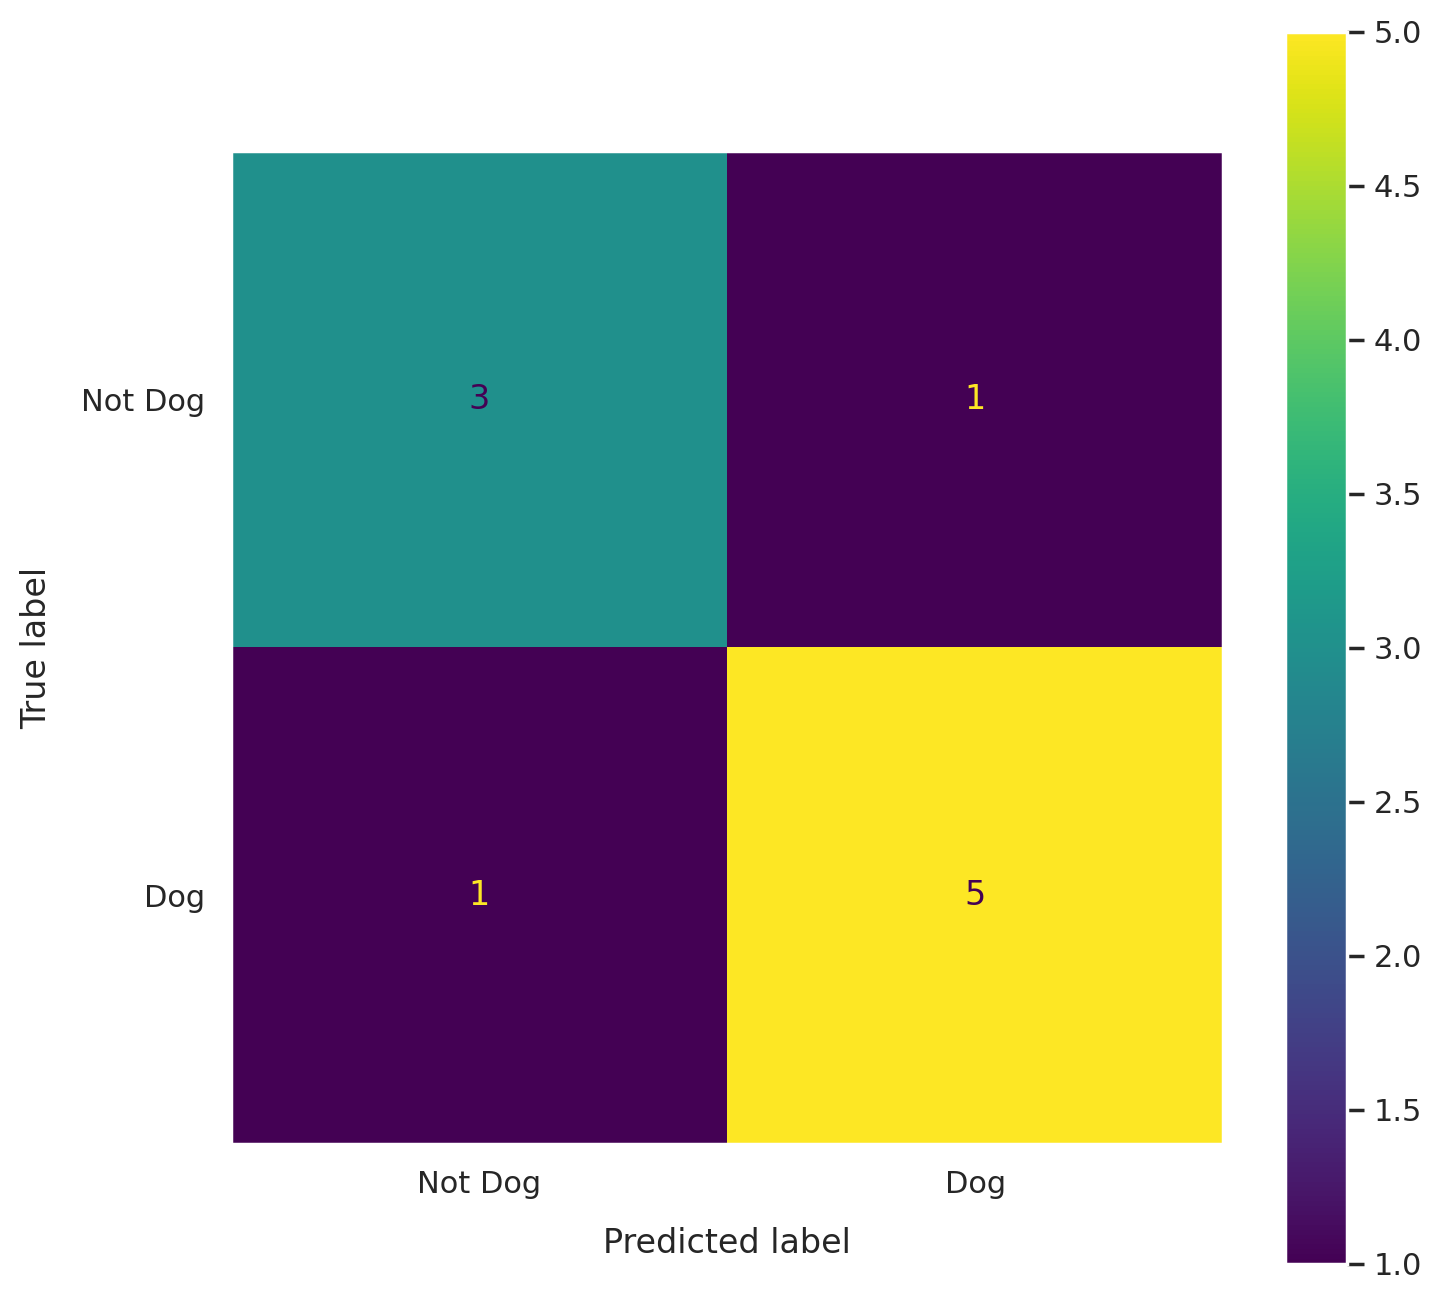

In [ ]:
actual    = np.array(
  ['Dog','Dog','Dog','Not Dog','Dog','Not Dog','Dog','Dog','Not Dog','Not Dog'])
predicted = np.array(
  ['Dog','Not Dog','Dog','Not Dog','Dog','Dog','Dog','Dog','Not Dog','Not Dog'])

cm = confusion_matrix(actual,predicted,labels=['Not Dog','Dog'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Not Dog','Dog'])
disp.plot()
plt.grid(False)
plt.show()

**Note to Calculate Confusion Matrix with 3 Classes**


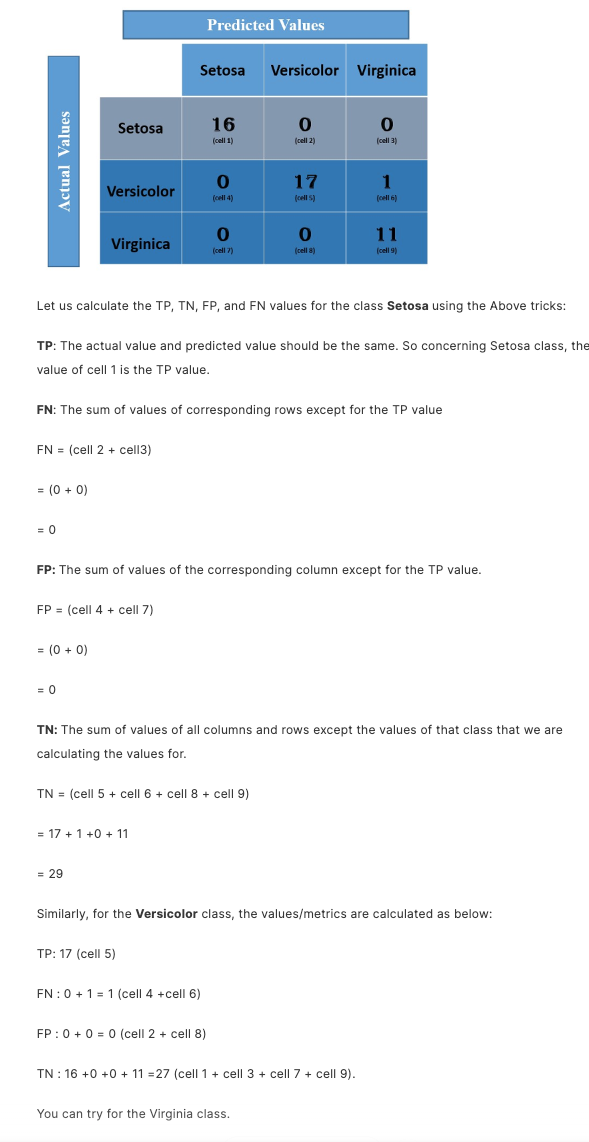

## Decision Trees.

Decision Tree algorithms are a type of probability tree-like structural model that continuously separates data in order to categorize or make predictions depending on the results of the previous set of questions. The model analyzes the data and provides responses to the questions in order to assist you in making more informed choices.

You could, for instance, utilize a decision tree in which the answers Yes or No are used to select a certain species of bird based on data elements like the bird's feathers, its ability to fly or swim, the sort of beak it has, and so on.


<img src="https://images.datacamp.com/image/upload/v1661171232/Decision_Tree_a8f0ed7248.gif" alt="drawing" width="600"/>

<table>
<tbody>
<tr>
<td>
<p class="p-margin">PROS</p>
</td>
<td>
<p class="p-margin">CONS</p>
</td>
</tr>
<tr>
<td>
<p class="p-margin">Very intuitive and easy to explain</p>
</td>
<td>
<p class="p-margin">Instable - a small change in training data can cause huge differences in prediction.</p>
</td>
</tr>
<tr>
<td>
<p class="p-margin">Decision trees don't require a lot of data preparation as some linear models require.</p>
</td>
<td>
<p class="p-margin">Prone to overfitting</p>
</td>
</tr>
</tbody>
</table>


### Introduction to Decision Trees
Decision Trees are a fundamental supervised learning algorithm in machine learning, widely used for both classification and regression tasks. They are intuitive, easy to interpret, and can handle complex data by recursively partitioning it into smaller subsets based on specific conditions.

Decision Trees consist of three main types of nodes: the root node, decision nodes, and leaf nodes. The root node represents the entire dataset, decision nodes are where the data is split based on certain conditions, and leaf nodes represent the predicted class or value.

### How Decision Trees Work

The process starts with the root node, which contains the entire dataset. The algorithm selects the best attribute to split the data at each decision node, typically using metrics like entropy, information gain, or the Gini index to determine the attribute that results in the most homogeneous sub-nodes. This splitting process is repeated for each new subset of data until a stopping criterion is met, such as all instances belonging to the same class or reaching a predefined depth.

### Prediction at Leaf Nodes

Once the tree is constructed, new data can be classified or regressed by traversing the tree from the root to a leaf node based on the attribute values. The prediction at the leaf node is determined as follows:

- **Classification**: In classification tasks, the leaf node predicts the class with the highest probability based on the distribution of classes in that node. This probability is calculated as the fraction of training samples of each class in the leaf node.
- **Regression**: For regression tasks, the leaf node predicts the average outcome of the training data in that node. This means that the predicted value is the mean of all target values of the instances that end up in that leaf node.


### Algorithms Used in Decision Trees

Several algorithms are used to construct Decision Trees, including ID3, C4.5, and CART. ID3 uses entropy to decide splits, while C4.5 is an extension that handles missing values and continuous attributes. CART can handle both classification and regression tasks.

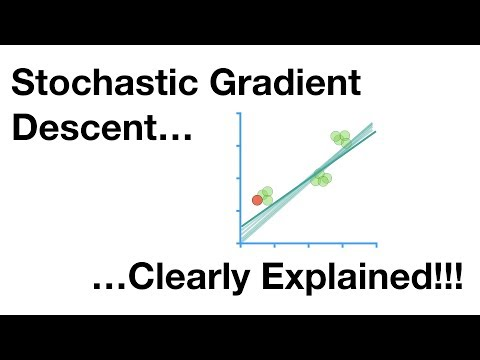

In [ ]:
from IPython.display import YouTubeVideo
YouTubeVideo("vMh0zPT0tLI",560,315,rel=0)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.94      0.94      0.94        18
   virginica       0.93      0.93      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



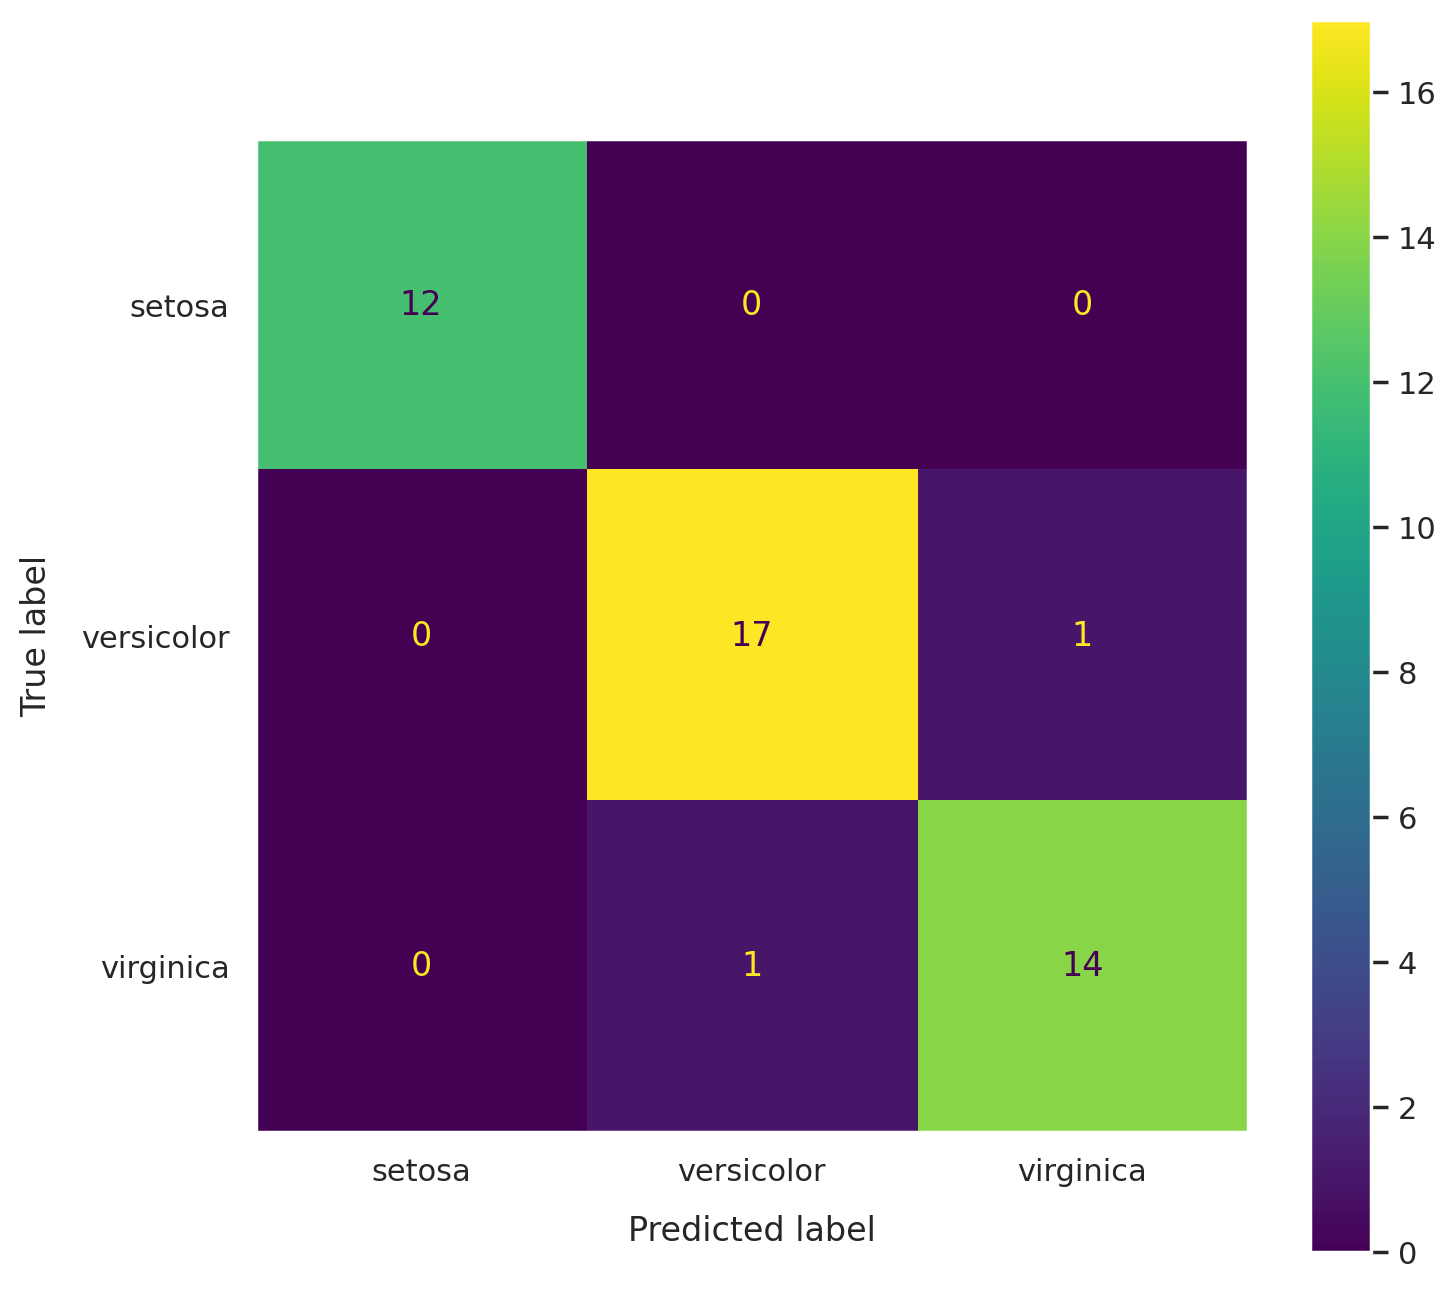

Accuracy is 0.9555555555555556


In [ ]:
# Decision Tree's
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier()
#Decision trees don't require a lot of data preparation. In particular, they don't require feature scaling or centering at all.
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

# Summary of the predictions made by the classifier
print(classification_report(y_test, y_pred,target_names=encode.classes_))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred),
                              display_labels=encode.classes_)
disp.plot()
plt.grid(False)
plt.show()
# Accuracy score
from sklearn.metrics import accuracy_score
print('Accuracy is',accuracy_score(y_pred,y_test))

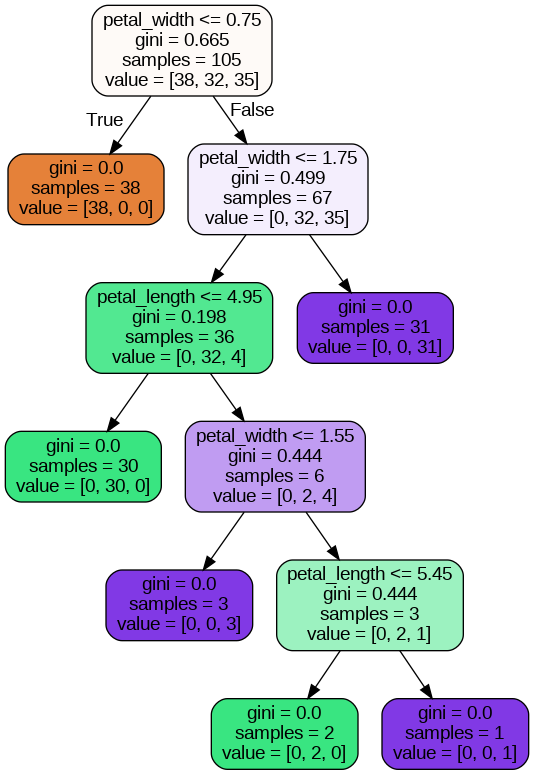

In [ ]:
# Plotting of decission tree
from IPython.display import Image
from sklearn.tree import export_graphviz
# Defining an object for DTC and fitting
dot_data = export_graphviz(classifier, out_file=None, feature_names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'],filled=True,rounded=True)
graph = pydotplus.graph_from_dot_data(dot_data.replace("\n",""))
Image(graph.create_png())

### Hyperparameter tuning using Grid Search and K-Folds


<img src="https://scikit-learn.org/stable/_images/grid_search_workflow.png" alt="drawing" width="600"/>

In [ ]:
from sklearn.model_selection import GridSearchCV
# Create the parameter grid
param_grid = {
    'max_depth': range(1, 10, 1),
    'min_samples_leaf': range(1, 40, 2),
    'min_samples_split': range(2, 30, 2),
    'criterion': ["entropy", "gini"]
}

n_folds = 5

# Instantiate the grid search model
iristree = DecisionTreeClassifier()
grid_search = GridSearchCV(estimator = iristree, param_grid = param_grid,
                          cv = n_folds, verbose = 1)

# Fit the grid search to the data
grid_search.fit(X_train,y_train)

Fitting 5 folds for each of 5040 candidates, totalling 25200 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['entropy', 'gini'],
                         'max_depth': range(1, 10),
                         'min_samples_leaf': range(1, 40, 2),
                         'min_samples_split': range(2, 30, 2)},
             verbose=1)

In [ ]:
# cv results
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.003297,0.001049,0.002334,0.000651,entropy,1,1,2,"{'criterion': 'entropy', 'max_depth': 1, 'min_...",0.714286,0.714286,0.714286,0.666667,0.666667,0.695238,0.023328,3137
1,0.002278,0.000136,0.001760,0.000182,entropy,1,1,4,"{'criterion': 'entropy', 'max_depth': 1, 'min_...",0.714286,0.714286,0.714286,0.666667,0.666667,0.695238,0.023328,3137
2,0.002488,0.000448,0.001726,0.000208,entropy,1,1,6,"{'criterion': 'entropy', 'max_depth': 1, 'min_...",0.714286,0.714286,0.714286,0.666667,0.666667,0.695238,0.023328,3137
3,0.003143,0.000351,0.002577,0.000850,entropy,1,1,8,"{'criterion': 'entropy', 'max_depth': 1, 'min_...",0.714286,0.714286,0.714286,0.666667,0.666667,0.695238,0.023328,3137
4,0.002229,0.000174,0.001645,0.000079,entropy,1,1,10,"{'criterion': 'entropy', 'max_depth': 1, 'min_...",0.714286,0.714286,0.714286,0.666667,0.666667,0.695238,0.023328,3137
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5035,0.002229,0.000099,0.001621,0.000038,gini,9,39,20,"{'criterion': 'gini', 'max_depth': 9, 'min_sam...",0.714286,0.714286,0.714286,0.666667,0.666667,0.695238,0.023328,3137
5036,0.002266,0.000311,0.001697,0.000147,gini,9,39,22,"{'criterion': 'gini', 'max_depth': 9, 'min_sam...",0.714286,0.714286,0.714286,0.666667,0.666667,0.695238,0.023328,3137
5037,0.002229,0.000172,0.001643,0.000121,gini,9,39,24,"{'criterion': 'gini', 'max_depth': 9, 'min_sam...",0.714286,0.714286,0.714286,0.666667,0.666667,0.695238,0.023328,3137
5038,0.002072,0.000034,0.001540,0.000062,gini,9,39,26,"{'criterion': 'gini', 'max_depth': 9, 'min_sam...",0.714286,0.714286,0.714286,0.666667,0.666667,0.695238,0.023328,3137


In [ ]:
# printing the optimal accuracy score and hyperparameters
print("best accuracy", grid_search.best_score_)
print(grid_search.best_estimator_)

best accuracy 0.9714285714285715
DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_leaf=3)


Running the model with Optimal Parameters

In [ ]:
# model with optimal hyperparameters
iristree1 = DecisionTreeClassifier(criterion = "entropy",
                                  random_state = 100,
                                  max_depth=4,
                                  min_samples_leaf=3,
                                  min_samples_split=2)
iristree1.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_leaf=3,
                       random_state=100)

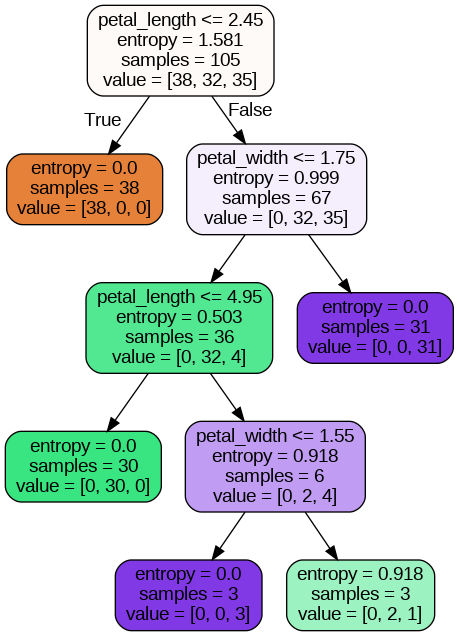

In [ ]:
# Defining an object for DTC and fitting
dot_data = export_graphviz(iristree1, out_file=None, feature_names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'],filled=True,rounded=True)
graph = pydotplus.graph_from_dot_data(dot_data.replace("\n",""))
Image(graph.create_png())

You can see that this tree is too complex to understand. Let's try reducing the max_depth and see how the tree looks.



In [ ]:
# tree with max_depth = 3
iristree2 = DecisionTreeClassifier(criterion = "gini",
                                  random_state = 100,
                                  max_depth=3,
                                  min_samples_leaf=4,
                                  min_samples_split=4)
iristree2.fit(X_train, y_train)

# score
print(iristree2.score(X_test,y_test))

0.9555555555555556


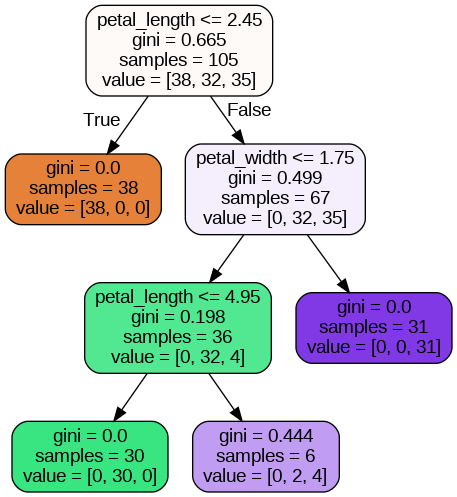

In [ ]:
# Defining an object for DTC and fitting
dot_data = export_graphviz(iristree2, out_file=None, feature_names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'],filled=True,rounded=True)
graph = pydotplus.graph_from_dot_data(dot_data.replace("\n",""))
Image(graph.create_png())

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.94      0.94      0.94        18
           2       0.93      0.93      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



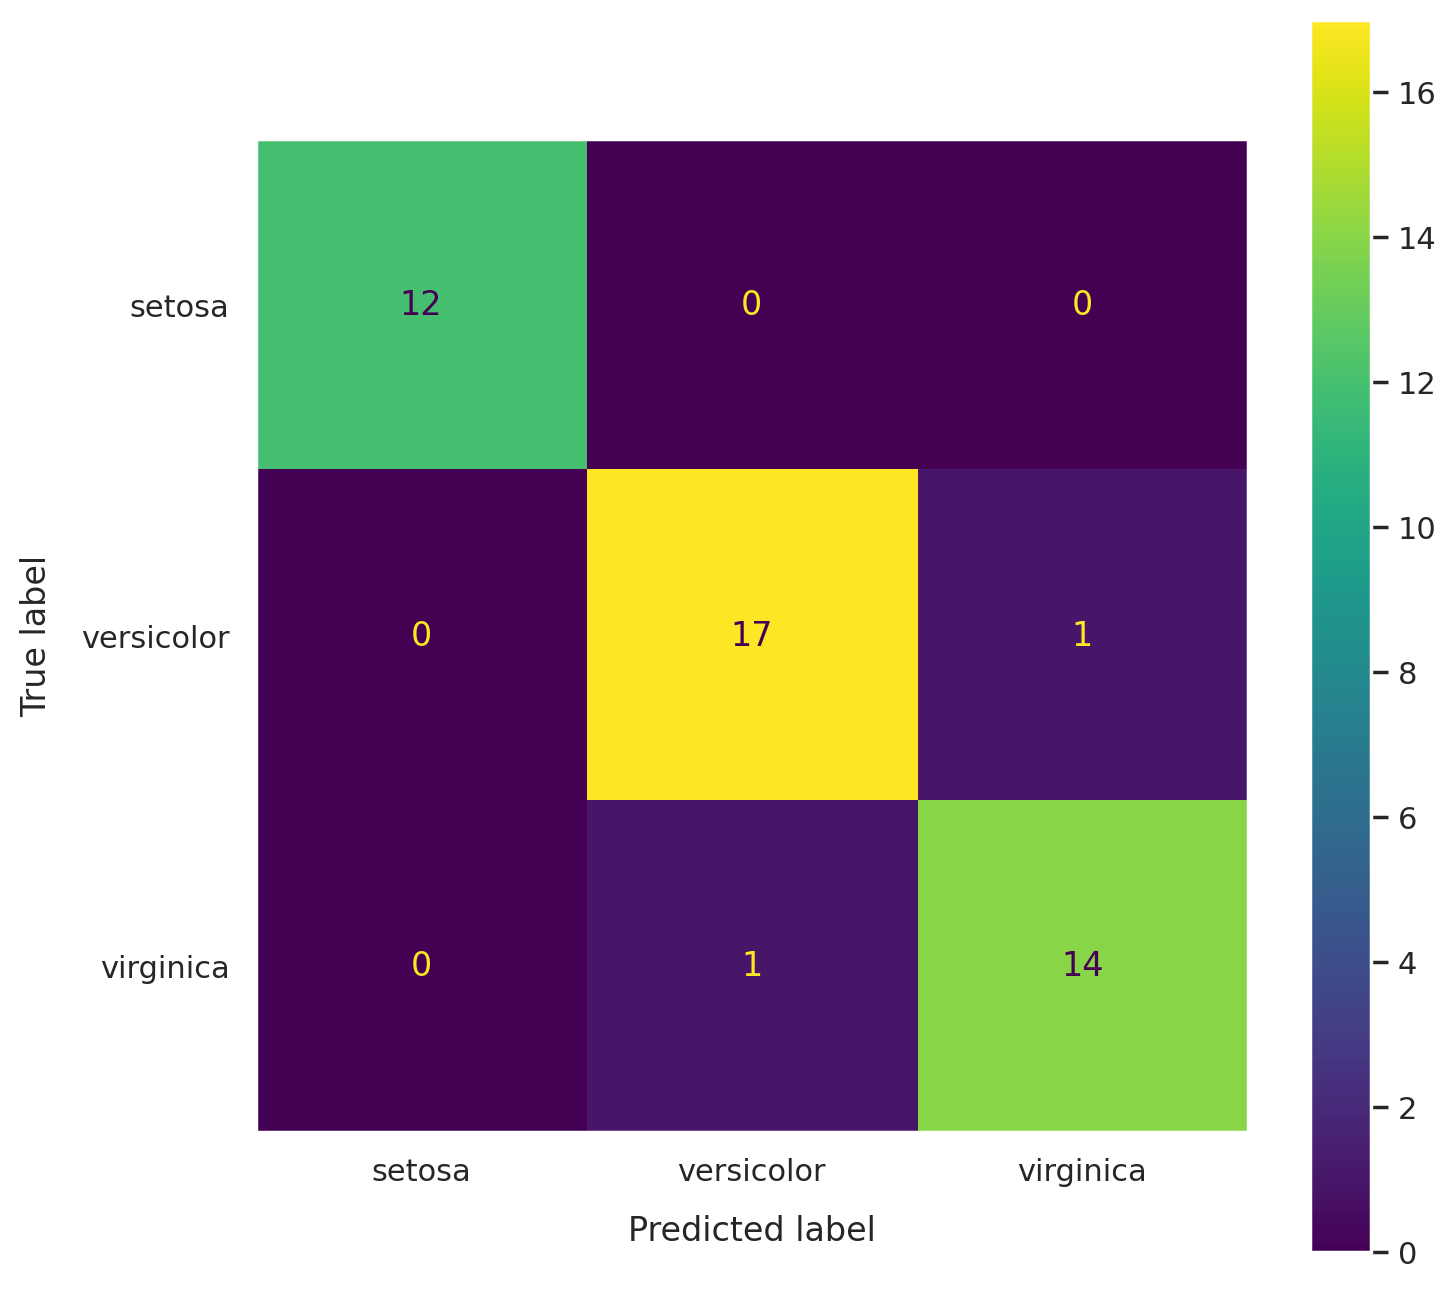

Accuracy is 0.9555555555555556


In [ ]:
y_pred = iristree1.predict(X_test)
print(classification_report(y_test, y_pred))
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred),
                              display_labels=encode.classes_)
disp.plot()
plt.grid(False)
plt.show()
# Accuracy score
from sklearn.metrics import accuracy_score
print('Accuracy is',accuracy_score(y_pred,y_test))

# Stochastic Gradient Descent (Classification) on Iris Dataset

Continuing with the same Dataset as before let us explore Stochastic Gradient Descent (SGD). It is an iterative optimization algorithm that is used to find the minimum of a function. SGD works by randomly selecting one data point at a time and updating the parameters of the model in the direction of the negative gradient of the function at that data point.

Stochastic Gradient Descent (SGD) is a simple yet very efficient approach to fitting linear classifiers and regressors under convex loss functions such as (linear) Support Vector Machines and Logistic Regression. Even though SGD has been around in the machine learning community for a long time, it has received a considerable amount of attention just recently in the context of large-scale learning.

Strictly speaking, SGD is merely an optimization technique and does not correspond to a specific family of machine learning models. It is only a way to train a model. Often, an instance of SGDClassifier or SGDRegressor will have an equivalent estimator in the scikit-learn API, potentially using a different optimization technique. For example, using SGDClassifier(loss='log_loss') results in logistic regression, i.e. a model equivalent to LogisticRegression which is fitted via SGD instead of being fitted by one of the other solvers in LogisticRegression.

<table>
<tbody>
<tr>
<td>
<p class="p-margin">PROS</p>
</td>
<td>
<p class="p-margin">CONS</p>
</td>
</tr>
<tr>
<td>
<p class="p-margin">Efficiency.</p>
</td>
<td>
<p class="p-margin">SGD requires a number of hyperparameters such as the regularization parameter and the number of iterations.</p>
</td>
</tr>
<tr>
<td>
<p class="p-margin">Ease of implementation (lots of opportunities for code tuning)</p>
</td>
<td>
<p class="p-margin">SGD is sensitive to feature scaling.</p>
</td>
</tr>
</tbody>
</table>


## Variations of SGD Based on Input

The variations of gradient descent with respect to input size are primarily categorized based on how much of the dataset is used to compute the gradient for each update.


1. **Batch Gradient Descent**: This method involves using the entire dataset to calculate the gradient for each parameter update. It's computationally expensive and can be slow for large datasets, but it provides a more stable gradient estimate.
2. **Mini-Batch Gradient Descent**: This approach uses a small subset of the data, known as a mini-batch, for each update. Mini-batch sizes are typically between 32 and 256 data points. It balances computational efficiency with gradient stability, making it a popular choice for many applications.
3. **Stochastic Gradient Descent (SGD)**: SGD uses only a single data point at a time to calculate the gradient. This method is computationally efficient but can result in noisy gradients, leading to less stable convergence. However, it can be effective for very large datasets or when computational resources are limited.

![Image in a markdown cell](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*FXHp55rpDM0tkaD5oz3Dvg.png)

## Implementing a Logistic Regression Binary Classifier from Scratch for Iris Dataset

To understand and implement the algorithm, you must understand six equations


1. To perform a prediction you have weights (w), inputs (x) and bias (b). as shown below.
$\large z = (\sum_{i=1}^{n} w_i x_i )+ b$

   However, it's common to use vector notation. This means that w becomes a list of values (in Python terms). Vector notation enables you to use faster computation time, which can be highly beneficial if you want to do rapid prototyping with a larger data set. You write a list of values with bolder characters, for example, the vector w, and you can rewrite your equation above the following equation.

    $\large z = w.x +b$


2. Furthermore, to get your prediction, you must use an activation function. In the case of binary logistic regression, it is called the sigmoid and is usually denoted by the Greek letter sigma. Another common notation is ŷ (yhat).
$\large \hat{y} = \sigma(z) = \begin{cases} \frac{1}{1 + exp(-z)}, & \text{if } z \geq 0 \\\frac{exp(z)}{1 + exp(z)}, & \text{otherwise}\end{cases}$

   You can visualize the sigmoid function by the following graph.

   <img src="https://miro.medium.com/v2/resize:fit:1400/1*5a-aTSS9wx89ZKcZTCljpA.png" width="500">


3. After you have the prediction, you can apply the basic gradient descent algorithm to optimize your model parameters, which are the weights and bias in this case.

 $\Large \theta_{t+1} = \theta_t - \eta \nabla L(f(x; \theta), y)$

 The scary part for is the unknown parameters and Greek letters, so the following list gives explanations.

 * $\theta$ (theta) is the parameter. For example, your weights or bias.
 * $\theta_t$ is the current value of the parameter.
 * $\theta_{t+1}$ is the next value of the parameter.
 * $\eta$ (eta) is the learning rate, which is usually set to a value between 0.1 and 0.0001.
 * $\nabla L$ refers to the gradients (∇, nabla) of the ($L$)oss function(given below). It takes in your inputs ($x$), your parameter values ($\theta$), and the labels ($y$).


4. The loss function (also known as a cost function) is a function that is used to measure how much your prediction differs from the labels. Binary cross entropy is the function that is used for the binary logistic regression algorithm, which yields the error value.$\Large L_{CE}(\hat{y}, y) = -\frac{1}{m}\sum_{i=1}^{m} y_i log(\hat{y}_i) + (1 - y_i) log(1 - \hat{y}_i)$

 Looking at the plus sign in the equation, if y = 0, then the left side is equal to 0, and if y = 1, then the right side is equal to 0. Effectively, this is how you measure how much your prediction ŷ differs from label y, which can only be 0 or 1 in a binary classification algorithm.


5. Now, to calculate the gradients to optimize your weights using gradient descent, you must calculate the derivative of your loss function. In other words, you must calculate the partial derivative of binary cross entropy. You can compactly describe the derivative of the loss function as seen as follows. The two equations represent the gradient of the Binary Cross-Entropy loss function with respect to the weights (w) and biases (b) in a binary logistic regression model. They are used to update the model's parameters during the training process.

  $\Large \frac{\partial L_{CE}(\hat{y}, y)}{\partial w} = \frac{1}{m}(\hat{y} - y)x_i^T$ and
  $\Large \frac{\partial L_{CE}(\hat{y}, y)}{\partial b} = \frac{1}{m}(\hat{y} - y)$





<img src="https://images.datacamp.com/image/upload/v1661171230/Logistic_Regression_50731b4db3.png" alt="drawing" width="600"/>


![Image in a markdown cell](https://miro.medium.com/v2/resize:fit:1400/0*lzNKQdsjFVaymJTF.gif)


In [ ]:
data #Iris Dataset

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [ ]:
# Get the mapping of classes to encoded values
class_mapping = dict(zip(encode.classes_, encode.transform(encode.classes_)))
print("Class Mapping:", class_mapping)

Class Mapping: {'setosa': 0, 'versicolor': 1, 'virginica': 2}


In [ ]:
# Take only 2 classes, and 2 features (sepal length/width)
# Select only the first two classes: Setosa and Versicolor
filtered_data = data[data['species'].isin([0, 1])]
# Select only the first two features: sepal length and sepal width
subset_data = filtered_data[['sepal_length', 'sepal_width', 'species']]
print(subset_data.head())

   sepal_length  sepal_width  species
0           5.1          3.5        0
1           4.9          3.0        0
2           4.7          3.2        0
3           4.6          3.1        0
4           5.0          3.6        0


In [ ]:
X_lg = preprocessing.scale(subset_data[['sepal_length', 'sepal_width']])
y_lg = subset_data['species'].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(X_lg, y_lg, test_size=0.2)

### Steps in Logistic Regression using SGD

1. Initialization: Start with random values for the model's weights (coefficients) and bias.

2. Iterate through the training data: For a specified number of epochs, repeat the following steps for each data point:

 * Randomly shuffle the dataset: Ensure data points are processed in a random order, preventing bias in parameter updates.
 * Calculate the prediction: Use the current parameters and the input data point to predict the probability of the target class using the sigmoid function.
 * Compute the gradient: Calculate the gradient of the log-loss function with respect to the model parameters for the current data point. The gradient indicates the direction and magnitude of the steepest increase in the loss function.
 * Update the parameters: Adjust the weights and bias based on the calculated gradient, using a learning rate to control the step size. Move in the direction opposite the gradient to minimize the loss function.

3. Repeat: Continue iterating until convergence (the loss function stabilizes) or a maximum number of epochs is reached.

In [ ]:
# Define a function named sigmoid that computes the sigmoid of a given input z.
# The sigmoid function maps any real-valued number to a value between 0 and 1.
def sigmoid(z):
    # Calculate the sigmoid of z using the formula: 1 / (1 + exp(-z)).
    # This formula is derived from the mathematical definition of the sigmoid function.
    return 1 / (1 + np.exp(-z))

# Define a function named fit_logistic_sgd that implements logistic regression using stochastic gradient descent (SGD).
# This function takes in the training data X, the target variable y, the learning rate, and the number of epochs.
def fit_logistic_sgd(X, y, learning_rate=0.01, epochs=1000):
    """
    X: A 2D NumPy array where each row represents a sample and each column represents a feature.
    y: A 1D NumPy array containing the binary labels (0 or 1) for each sample.
    learning_rate: The step size for each gradient descent update. Default is 0.01.
    epochs: The number of times the algorithm iterates through the entire dataset. Default is 1000.
    Returns: A tuple containing the optimized weights and bias.
    """

    # Get the number of samples (rows) and features (columns) in the dataset X.
    n_samples, n_features = X.shape

    # Initialize the weights as a NumPy array filled with zeros, with the same number of elements as features.
    # These weights will be adjusted during the training process.
    weights = np.zeros(n_features)

    # Initialize the bias term as a scalar value, starting at 0.0.
    # The bias shifts the decision boundary and is crucial for accurate predictions.
    bias = 0.0

    # Iterate through the specified number of epochs.
    for epoch in range(epochs):
        # For each epoch, iterate through every sample in the dataset.
        # Shuffle the indices for random selection
        indices = np.random.permutation(n_samples)
        for i in indices:
            # Compute the linear combination of the current sample's features and the weights, then add the bias.
            # This linear combination is used to predict the probability of the sample belonging to class 1.
            z = np.dot(X[i], weights) + bias

            # Apply the sigmoid function to the linear combination to obtain the predicted probability.
            y_pred = sigmoid(z)

            # Calculate the error between the predicted probability and the actual label.
            # This error drives the gradient descent updates.

            error = y_pred - y[i]

            # Compute the gradients of the loss with respect to the weights and bias.
            # These gradients indicate the direction of the steepest ascent in the loss function.
            grad_weights = error * X[i]  # Gradient for weights
            grad_bias = error  # Gradient for bias

            # Update the weights and bias by subtracting the product of the learning rate and the gradients.
            # This step moves the model parameters in the direction that minimizes the loss.
            weights -= learning_rate * grad_weights
            bias -= learning_rate * grad_bias

        # After completing each epoch, compute and print the accuracy and cost.
        predictions = predict(X, weights, bias)
        accuracy = np.mean(predictions == y) * 100
        cost = np.mean(-y * np.log(predict_proba(X, weights, bias)) - (1-y) * np.log(1 - predict_proba(X, weights, bias)))

        # Print the epoch number, accuracy, and cost.
        print(f"Epoch: {epoch} | Accuracy: {accuracy:.4f} | Cost: {cost:.4f}")

    # After completing all epochs, return the optimized weights and bias.
    return weights, bias

# Define a function named predict_proba that computes the predicted probabilities for new samples.
def predict_proba(X, weights, bias):
    # Compute the linear combination of the new samples' features and the optimized weights, then add the bias.
    # This step is similar to the prediction step during training but is applied to new, unseen data.
    z = np.dot(X, weights) + bias

    # Apply the sigmoid function to obtain the predicted probabilities.
    return sigmoid(z)

# Define a function named predict that generates binary predictions based on the predicted probabilities.
def predict(X, weights, bias, threshold=0.5):
    # Compute the predicted probabilities using the predict_proba function.
    # These probabilities represent the likelihood of each sample belonging to class 1.
    probas = predict_proba(X, weights, bias)

    # Convert the probabilities into binary predictions by comparing them to a threshold (default is 0.5).
    # Samples with probabilities greater than or equal to the threshold are classified as class 1; otherwise, they are classified as class 0.
    return (probas >= threshold).astype(int)

In [ ]:
# Train
weights, bias = fit_logistic_sgd(X_train, y_train, learning_rate=0.1, epochs=25)

# Predict
print("Weights:", weights)
print("Bias:", bias)
print("Probabilities:", predict_proba(X_test, weights, bias))
print("Predictions:", predict(X_test, weights, bias))
print('Accuracy is',accuracy_score(predict(X_test, weights, bias),y_test))

Epoch: 0 | Accuracy: 100.0000 | Cost: 0.1835
Epoch: 1 | Accuracy: 100.0000 | Cost: 0.1182
Epoch: 2 | Accuracy: 100.0000 | Cost: 0.0907
Epoch: 3 | Accuracy: 100.0000 | Cost: 0.0750
Epoch: 4 | Accuracy: 100.0000 | Cost: 0.0646
Epoch: 5 | Accuracy: 100.0000 | Cost: 0.0571
Epoch: 6 | Accuracy: 100.0000 | Cost: 0.0514
Epoch: 7 | Accuracy: 100.0000 | Cost: 0.0469
Epoch: 8 | Accuracy: 100.0000 | Cost: 0.0433
Epoch: 9 | Accuracy: 100.0000 | Cost: 0.0402
Epoch: 10 | Accuracy: 100.0000 | Cost: 0.0376
Epoch: 11 | Accuracy: 100.0000 | Cost: 0.0354
Epoch: 12 | Accuracy: 100.0000 | Cost: 0.0334
Epoch: 13 | Accuracy: 100.0000 | Cost: 0.0317
Epoch: 14 | Accuracy: 100.0000 | Cost: 0.0302
Epoch: 15 | Accuracy: 100.0000 | Cost: 0.0288
Epoch: 16 | Accuracy: 100.0000 | Cost: 0.0276
Epoch: 17 | Accuracy: 100.0000 | Cost: 0.0265
Epoch: 18 | Accuracy: 100.0000 | Cost: 0.0255
Epoch: 19 | Accuracy: 100.0000 | Cost: 0.0245
Epoch: 20 | Accuracy: 100.0000 | Cost: 0.0237
Epoch: 21 | Accuracy: 100.0000 | Cost: 0.022

## Implementing a Logistic Regression using SGD Classifier

SGDClassifier supports multi-class classification by combining multiple binary classifiers in a “one versus all” (OVA) scheme.The dashed lines represent the three OVA classifiers; the background colors show the decision surface induced by the three classifiers.

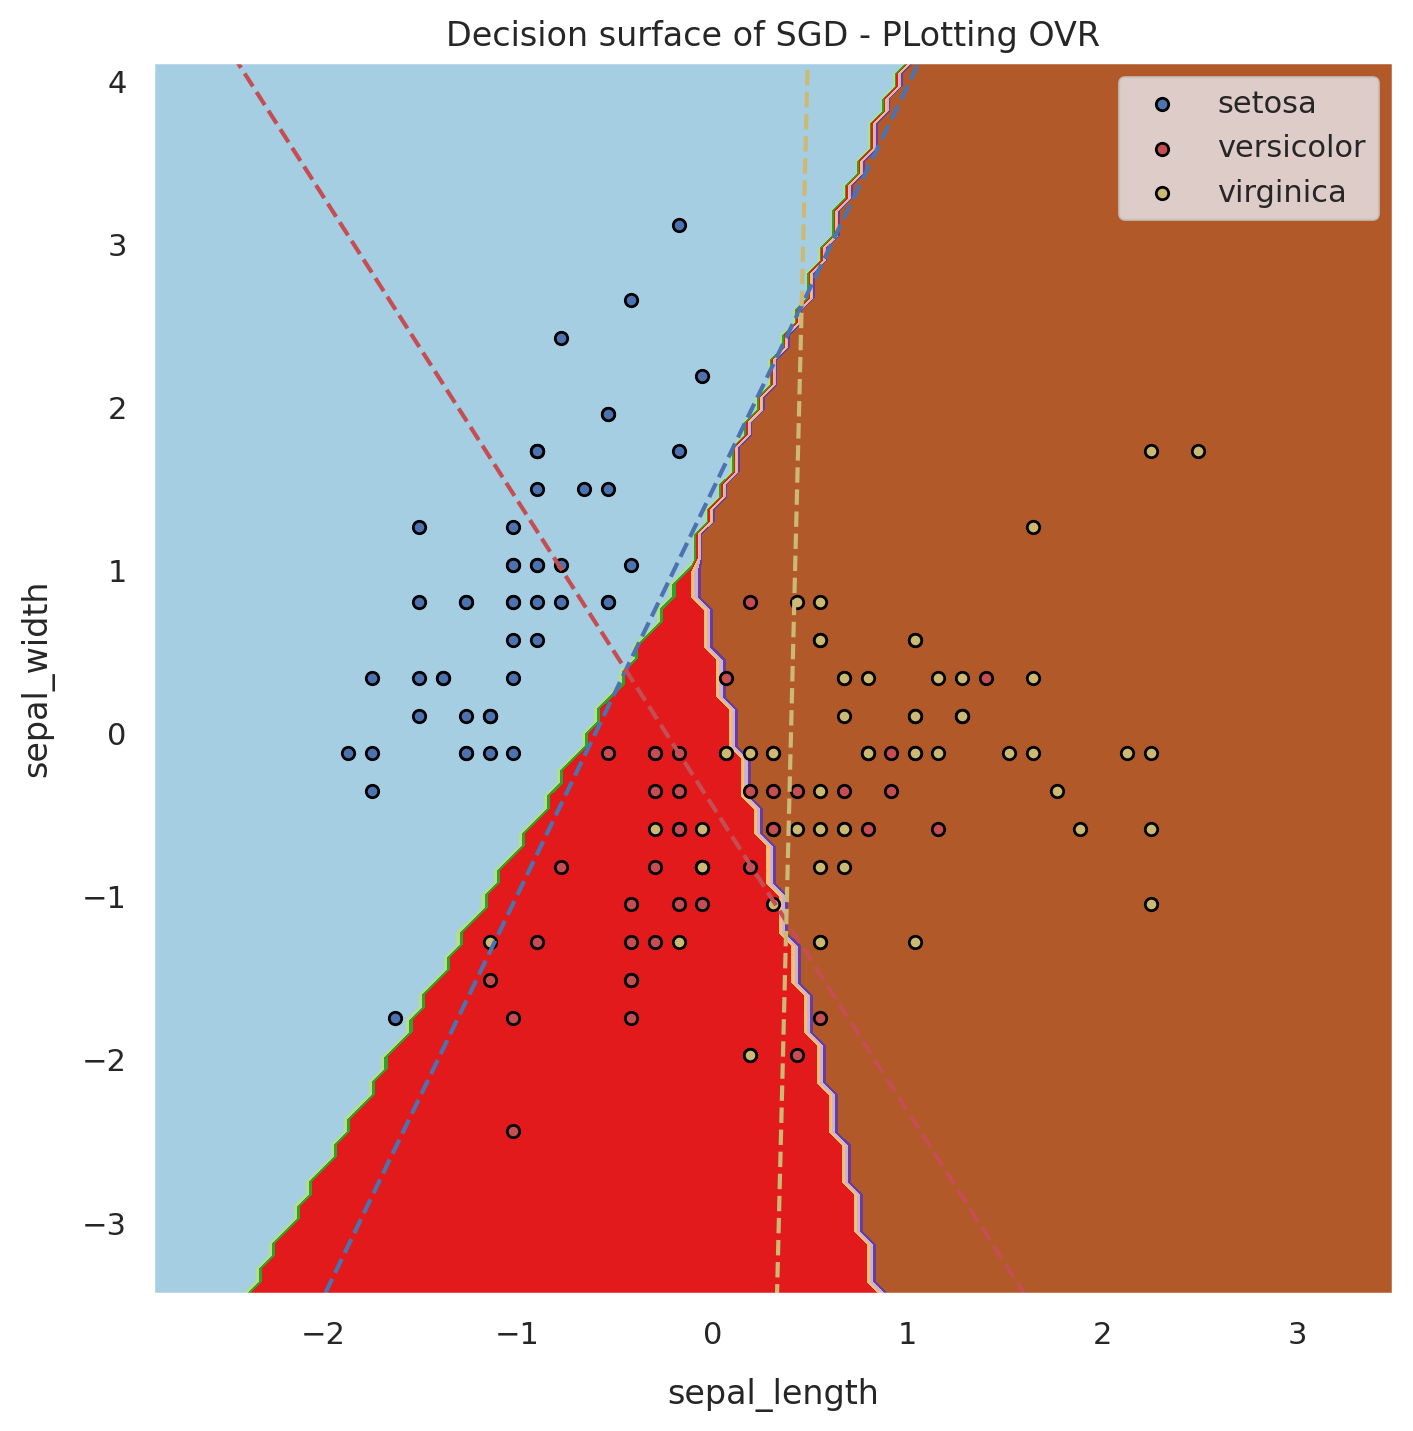

In [ ]:
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import SGDClassifier


# we only take the first two features.
# Select only the two features: sepal length and sepal width
subset_data = data[['sepal_length', 'sepal_width', 'species']]
X = preprocessing.scale(subset_data[['sepal_length', 'sepal_width']])
y = subset_data['species'].to_numpy()
colors = "bry"

# shuffle
idx = np.arange(X.shape[0])
np.random.seed(13)
np.random.shuffle(idx)
X = X[idx]
y = y[idx]

# standardize
mean = X.mean(axis=0)
std = X.std(axis=0)
X = (X - mean) / std

clf = SGDClassifier(loss='log_loss',penalty=None, max_iter=1000).fit(X, y).fit(X, y)
ax = plt.gca()
DecisionBoundaryDisplay.from_estimator(
    clf,
    X,
    cmap=plt.cm.Paired,
    ax=ax,
    response_method="predict",
    xlabel="sepal_length",
    ylabel="sepal_width",
)
plt.axis("tight")
target_names=['setosa', 'versicolor','virginica']
# Plot also the training points
for i, color in zip(clf.classes_, colors):
    idx = np.where(y == i)
    plt.scatter(
        X[idx, 0],
        X[idx, 1],
        c=color,
        label=target_names[i],
        edgecolor="black",
        s=20,
    )
plt.title("Decision surface of SGD - PLotting OVR")
plt.axis("tight")

# Plot the three one-against-all classifiers
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
coef = clf.coef_
intercept = clf.intercept_


def plot_hyperplane(c, color):
    def line(x0):
        return (-(x0 * coef[c, 0]) - intercept[c]) / coef[c, 1]

    plt.plot([xmin, xmax], [line(xmin), line(xmax)], ls="--", color=color)


for i, color in zip(clf.classes_, colors):
    plot_hyperplane(i, color)
plt.legend()
plt.show()

## Implement One-vs-One (OvO) and One-vs-Rest (OvR) Strategies

In [ ]:
# Dataset
X_sgd = preprocessing.scale(data[['sepal_length', 'sepal_width','petal_length','petal_width']])
y_sgd = data['species'].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(X_sgd, y_sgd, test_size=0.2)

SGDClassifier(loss='log_loss', max_iter=1000) is equivalent to logistic regression because it uses stochastic gradient descent (SGD) to optimize the log loss function, which is the same objective function used in logistic regression.

In [ ]:
# Logistic Regression with SGDClassifier
sgd_logistic_model = SGDClassifier(loss='log_loss',penalty=None,max_iter=1000)
sgd_logistic_model.fit(X_train, y_train)
sgd_logistic_pred = sgd_logistic_model.predict(X_test)
sgd_logistic_accuracy = accuracy_score(y_test, sgd_logistic_pred)
print(f"SGD Logistic Regression Accuracy: {sgd_logistic_accuracy}")

SGD Logistic Regression Accuracy: 1.0


Implement One-vs-One (OvO) and One-vs-Rest (OvR) Strategies
For OvO and OvR strategies, you can use the OneVsOneClassifier and OneVsRestClassifier wrappers, respectively. SGDClassifier in scikit-learn can handle multi-class classification natively. However when using OvO or OvR with SGDClassifier, scikit-learn automatically handles the conversion to binary classification problems.



In [ ]:
# One-vs-One (OvO) using SGDClassifier
from sklearn.multiclass import OneVsOneClassifier
ovo_sgd_model = OneVsOneClassifier(SGDClassifier(loss='log_loss',penalty=None,max_iter=1000))
ovo_sgd_model.fit(X_train, y_train)
ovo_sgd_pred = ovo_sgd_model.predict(X_test)
ovo_sgd_accuracy = accuracy_score(y_test, ovo_sgd_pred)
print(f"OvO SGD Logistic Regression Accuracy: {ovo_sgd_accuracy}")

OvO SGD Logistic Regression Accuracy: 1.0


In [ ]:
# One-vs-Rest (OvR) using SGDClassifier
from sklearn.multiclass import OneVsRestClassifier
ovr_sgd_model = OneVsRestClassifier(SGDClassifier(loss='log_loss',penalty=None, max_iter=1000))
ovr_sgd_model.fit(X_train, y_train)
ovr_sgd_pred = ovr_sgd_model.predict(X_test)
ovr_sgd_accuracy = accuracy_score(y_test, ovr_sgd_pred)
print(f"OvR SGD Logistic Regression Accuracy: {ovr_sgd_accuracy}")

OvR SGD Logistic Regression Accuracy: 1.0


# Neural Networks and Multilabel Classification

To play around and Interact with Neural Networks the [Tensorflow Playground ](https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.97093&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false) is a great place.

Multi-layer perceptrons, or MLPs, are a powerful member of the Artificial Neural Networks family that can be used to solve complex problems that a single perceptron alone cannot. At their core, MLPs are complex and it has a collection of interconnected single perceptrons, also known as neurons or nodes, working together to process and analyze data.


The development of MLPs can be traced back to the 1950s when psychologist Frank Rosenblatt introduced the perceptron, a single-layer neural network. However, it was soon realized that single-layer perceptrons are very limited and they could not solve some complex problems. Due to its inability to solve major problems that scientists thought, Frank's perceptron began to lose popularity, and scientists and researchers at that time almost dropped the idea of Neural Networks altogether by focusing on other machine learning algorithms.


However, in the 1980s a computer scientist named Geoffrey Hinton comes up with a new idea. He noticed that the human brain is indeed a complex collection of neurons connected together and not just one. The biggest problem with perceptrons is that it is just a single-layer neural network, so he theorized that most of the limitations of perceptrons can be eliminated by stacking them together to form a multi-layer neural network, this idea proposed by Hinton leads to the emergence of a powerful algorithm, which is what we call "Multi-layer perceptron (MLP)"


![image.png](https://blogger.googleusercontent.com/img/b/R29vZ2xl/AVvXsEgxIM5ebUtSZ06KqB3p1Q3L1s_6pMKr0riYmEoj1-xyuT3kzDBOvxj9K9WJp-koQBvHe8BDtGH-PTjp8Gf9qku1Hj3l4XJbRXPAwRhSL6kHuXgCEy_cL09ri11hCmzRBltxpka1MgJbaARsI8PpijnMwcarTCn68i47xoeMEPKH2ngutLA0XLuYk0erpA/s1640/single%20and%20multi-layer%20perceptron%20image%20combined%202.png)

A Multi-layer perceptron (MLP) is a type of artificial neural network that is composed of multiple layers of interconnected "neurons". These neurons are modeled after the neurons in the human brain, which are used to learn complex data and to make meaningful predictions.


<table>
<tbody>
<tr>
<td>
<p class="p-margin">PROS</p>
</td>
<td>
<p class="p-margin">CONS</p>
</td>
</tr>
<tr>
<td>
<p class="p-margin">Handling Non-Linear Problems</p>
</td>
<td>
<p class="p-margin">MLP can be computationally intensive due to the backpropagation algorithm used for training.</p>
</td>
</tr>
<tr>
<td>
<p class="p-margin">MLPs are highly flexible in their architecture and can approximate any function under certain conditions</p>
</td>
<td>
<p class="p-margin">Risk of Overfitting - MLPs, especially those with multiple hidden layers, can suffer from overfitting</p>
</td>
</tr>
</tbody>
</table>




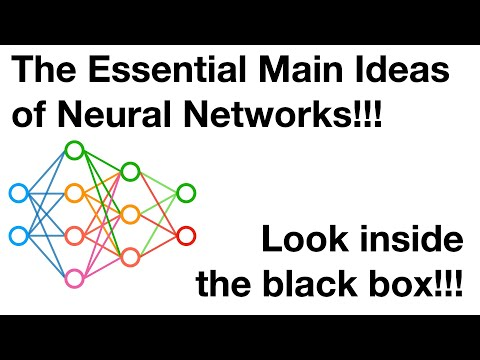

In [ ]:
from IPython.display import YouTubeVideo
YouTubeVideo("CqOfi41LfDw",560,315,rel=0)

### Multi-layer perceptrons working


A multi-layer perceptron (MLP) is composed of multiple layers of interconnected neurons. With our student's example, we can say that each neuron is like a student in the group, and each neuron is only able to perform simple arithmetic operations.
The structure of an MLP can be broken down into three main parts: the input layer, the hidden layers, and the output layer.


![image.png](https://blogger.googleusercontent.com/img/b/R29vZ2xl/AVvXsEhKeKxtLbxWMTxLOp-VdWuMh5UNd--5JV9I_H-YvbCTlRbc3xafp8gNKqH610s9ETLmt5U7dWWaS_K0USMlAzMgOaYRAe9MPrUJQiHkzNuvuhklnoOYk29kBYA28MCDqVAcF71eZnYfT1X5_bkMQIGBq0BYO7ObHhD6-2R_bub5jZuMi8exvoepazgXpw/w594-h334/Neural%20network%20structure.png)


Note that, the neurons in the input layer must be the size of the training instances, and the output layer must be the size of the output labels. However, there can be any number of neurons or layers in the hidden layer of the neural network according to the needs, So the more neurons in the hidden layer the more complex problem the network can solve.



When the data is input into the network, it is first passed through the input layer, in the input layer, there is no specific operation performed but it just transfers the input into the next layer which is the hidden layer. The neurons in the hidden layer perform some operation on the data and then it is passed to the next hidden layer if there is any. Finally, the processed data is passed to the output layer to produce the output.

In each of these neurons, we assign some weights and biases. The weights are what we call the heart of a Neural Network. Weights are basically used for determining the strength of the connection between neurons, For instance, if a neuron has a high weight, it means that it has a strong connection to the next neuron and its output will have a greater impact on the final output of the network.

On the other hand, if a neuron has a low weight, it means that it has a weaker connection to the next neuron and its output will have a lesser impact on the final output of the network.

The biases, on the other hand, are used to determine the level of activation of a neuron. A bias can be thought of as a threshold value that a neuron must reach before it produces an output.

If the input to a neuron plus its bias is greater than a certain value, the neuron will produce an output, otherwise, it will not. This allows the network to be more flexible and adaptable to different types of inputs.


![image.png](https://blogger.googleusercontent.com/img/b/R29vZ2xl/AVvXsEgZ1onrToMXESCQG6HBk-eOF9Hp1LYt_-dz8H4TcP_e4XkgECQyosZ7Y1NUAibzwGYvCllH2IfMrBHXE9RbH4C_KnhkOa3E382hst8LzqyfwUMTSdolM8GZha_w4shhNbRZIUFeS9H9c4Blwke5bKs5Jfn8-3gd_BhzsSptBBoYbD3YaJJCbYCV--xIvA/w584-h329/Neural%20network%20weights%20and%20bias%20(1).png)

The computation of each of the neuron inside the network can be given by:


![image.png](https://blogger.googleusercontent.com/img/b/R29vZ2xl/AVvXsEi0BRzdl_5S5uXtmZ3b7f8RD5u2y8bx_yfNThtjIyMBtmnt2tQZvSE44tUCVbQn9_kKk2mVSfacq8b_c-50pLADcFswSh5djs9uHQLQB2h58YG-3r1LSYDQ8NtjFIBuc8BfK6ZUgNeDcAuAGaREh1loqSIV8RaPBAJn2wZ6-kvgDCd0MfqwDtSTggPv4w/s320/CodeCogsEqn%20(1).png)


W = Weights of each neuron
X = inputs

This is known as the weighted sum of inputs, plus a bias. So when each neuron receives an input it will perform the weighted sum of inputs and adds a bias. The weighted sum of inputs is nothing but the dot product of the weights and inputs. This is exactly what happens inside each and every neuron inside the neural network.

But, there is something more important to note, Even if we find the weighted sum of inputs plus a bias in each case, it is nothing but purely a linear model, like Linear Regression. So if we want to do just a linear fit to the data, then why use complex Neural Networks like MLPs instead of simple Linear Regression? There is no difference between these two with this method, right?.

So here we need to bring a non-linearity to our MLP, and that is possible by introducing a non-linear function, specifically known as an Activation Function in the context of Neural Networks.

So in each neuron in the network, apart from finding the weighted sum of inputs and adding a bias, these results are also passed through an activation function to produce the output of each neuron which is a non-linear value. This non-linear value is then passed to the next layer and then the process is the same.


![image.png](
https://blogger.googleusercontent.com/img/b/R29vZ2xl/AVvXsEgRqaRDinW51u7Cj9nHFh5HQOLxj1b38K56A86VN_qO-zyZzjnuFMMcfcKp1ZZSDOeRf-DyZbQTYKAPNc6JJW-NRmrsN1KgHzT83sCYkB4z_8CVRXxYfoVAT1q9RGh3_oURruElHzy0yeFedZNg1zMKfWi6HG0NYkOSQ561_nxxL1x_D1kJLWe1b66y6w/w607-h342/Neural%20network%20weights%20and%20bias%20calc.png)



## Genre categorization of Netflix’s movies and shows using MLPs

The problem tackled here is the genre categorization of Netflix’s movies and shows, which can belong to more than one category at the same time (Multilabel Classification).

The dataset used is the Netflix Movies and TV Shows,This tabular dataset consists of listings of all the movies and tv shows available on Netflix, along with details such as - cast, directors, ratings, release year, duration, etc.

[For More Info](https://www.kaggle.com/datasets/shivamb/netflix-shows)

In [ ]:
titles = pd.read_csv('https://raw.githubusercontent.com/prasertcbs/basic-dataset/refs/heads/master/netflix_titles.csv')
titles.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...


Lets see the size of this dataset and its shape

In [ ]:
print(titles.shape)

(6234, 12)


### Data wrangling


In [ ]:
description_category = titles[['listed_in','description']].copy()
description_category['listed_in'] = description_category['listed_in'].apply(lambda x: x.split(', '))
description_category.head()

,listed_in,description
0,"[Children & Family Movies, Comedies]",Before planning an awesome wedding for his gra...
1,[Stand-Up Comedy],Jandino Asporaat riffs on the challenges of ra...
2,[Kids' TV],"With the help of three human allies, the Autob..."
3,[Kids' TV],When a prison ship crash unleashes hundreds of...
4,[Comedies],When nerdy high schooler Dani finally attracts...


In [ ]:
columns = ['category_1', 'category_2', 'category_3']
cat = pd.DataFrame(description_category['listed_in'].to_list(), columns = columns)
cat

,category_1,category_2,category_3
0,Children & Family Movies,Comedies,None
1,Stand-Up Comedy,None,None
2,Kids' TV,None,None
3,Kids' TV,None,None
4,Comedies,None,None
...,...,...,...
6229,TV Action & Adventure,TV Comedies,TV Sci-Fi & Fantasy
6230,TV Comedies,None,None
6231,Movies,None,None
6232,British TV Shows,TV Comedies,TV Dramas


In [ ]:
category_1_genres = cat.category_1.unique()
category_2_genres = cat.category_2.unique()
category_3_genres = cat.category_3.unique()

genres = np.concatenate([category_1_genres, category_2_genres, category_3_genres])
genres = list(dict.fromkeys(genres))
genres = [x for x in genres if x is not None]
len(genres)

42

In [ ]:
genres

['Children & Family Movies',
 'Stand-Up Comedy',
 "Kids' TV",
 'Comedies',
 'Crime TV Shows',
 'International Movies',
 'Docuseries',
 'Action & Adventure',
 'Cult Movies',
 'Documentaries',
 'Horror Movies',
 'Dramas',
 'International TV Shows',
 'Romantic TV Shows',
 'TV Comedies',
 'British TV Shows',
 'Anime Features',
 'Independent Movies',
 'Reality TV',
 'Anime Series',
 'TV Horror',
 'Movies',
 'Stand-Up Comedy & Talk Shows',
 'Thrillers',
 'TV Action & Adventure',
 'Classic Movies',
 'TV Dramas',
 'Music & Musicals',
 'Sci-Fi & Fantasy',
 'TV Shows',
 'Spanish-Language TV Shows',
 'Sports Movies',
 'Classic & Cult TV',
 'Romantic Movies',
 'TV Sci-Fi & Fantasy',
 'Science & Nature TV',
 'Korean TV Shows',
 'Teen TV Shows',
 'LGBTQ Movies',
 'TV Mysteries',
 'TV Thrillers',
 'Faith & Spirituality']

In [ ]:
cat = pd.concat([cat, pd.DataFrame(columns=list(genres))])
cat = cat.infer_objects(copy=False)
cat.fillna(0, inplace=True)
cat.head()

,category_1,category_2,category_3,Children & Family Movies,Stand-Up Comedy,Kids' TV,Comedies,Crime TV Shows,International Movies,Docuseries,...,Classic & Cult TV,Romantic Movies,TV Sci-Fi & Fantasy,Science & Nature TV,Korean TV Shows,Teen TV Shows,LGBTQ Movies,TV Mysteries,TV Thrillers,Faith & Spirituality
0,Children & Family Movies,Comedies,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Stand-Up Comedy,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Kids' TV,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Kids' TV,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Comedies,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
row = 0
for genre in cat['category_1']:
    if genre != 0:
        cat.loc[row, genre] = 1
    row = row + 1
row = 0
for genre in cat['category_2']:
    if genre != 0:
        cat.loc[row, genre] = 1
    row = row + 1
row = 0
for genre in cat['category_3']:
    if genre != 0:
        cat.loc[row, genre] = 1
    row = row + 1

description_category = pd.concat([description_category['description'],
                                     cat.loc[:,"Children & Family Movies":]],
                                    axis=1)
description_category

,description,Children & Family Movies,Stand-Up Comedy,Kids' TV,Comedies,Crime TV Shows,International Movies,Docuseries,Action & Adventure,Cult Movies,...,Classic & Cult TV,Romantic Movies,TV Sci-Fi & Fantasy,Science & Nature TV,Korean TV Shows,Teen TV Shows,LGBTQ Movies,TV Mysteries,TV Thrillers,Faith & Spirituality
0,Before planning an awesome wedding for his gra...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Jandino Asporaat riffs on the challenges of ra...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,"With the help of three human allies, the Autob...",0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,When a prison ship crash unleashes hundreds of...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,When nerdy high schooler Dani finally attracts...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6229,"This parody of first-person shooter games, mil...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6230,"Marc Maron stars as Marc Maron, who interviews...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6231,Nursery rhymes and original music for children...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6232,"Set during the Russian Revolution, this comic ...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


###EDA - Exploratory data analysis


In [ ]:
bar_plot = pd.DataFrame()
bar_plot['cat'] = description_category.columns[1:]
bar_plot['count'] = description_category.iloc[:,1:].sum().values
bar_plot.sort_values(['count'], inplace=True, ascending=False)
bar_plot.reset_index(inplace=True, drop=True)
bar_plot

,cat,count
0,International Movies,1927.0
1,Dramas,1623.0
2,Comedies,1113.0
3,International TV Shows,1001.0
4,Documentaries,668.0
5,TV Dramas,599.0
6,Action & Adventure,597.0
7,Independent Movies,552.0
8,TV Comedies,436.0
9,Thrillers,392.0


Now, it is nice to have a closer look at the most frequent genres among the titles and check the categories with too few data points.Some categories do not have enough data points, and it makes the prediction less precise. Therefore, We an arbitrary threshold of 200 titles, and the categories below the threshold are clustered together in a new category named Others, making a total of 21 genres.

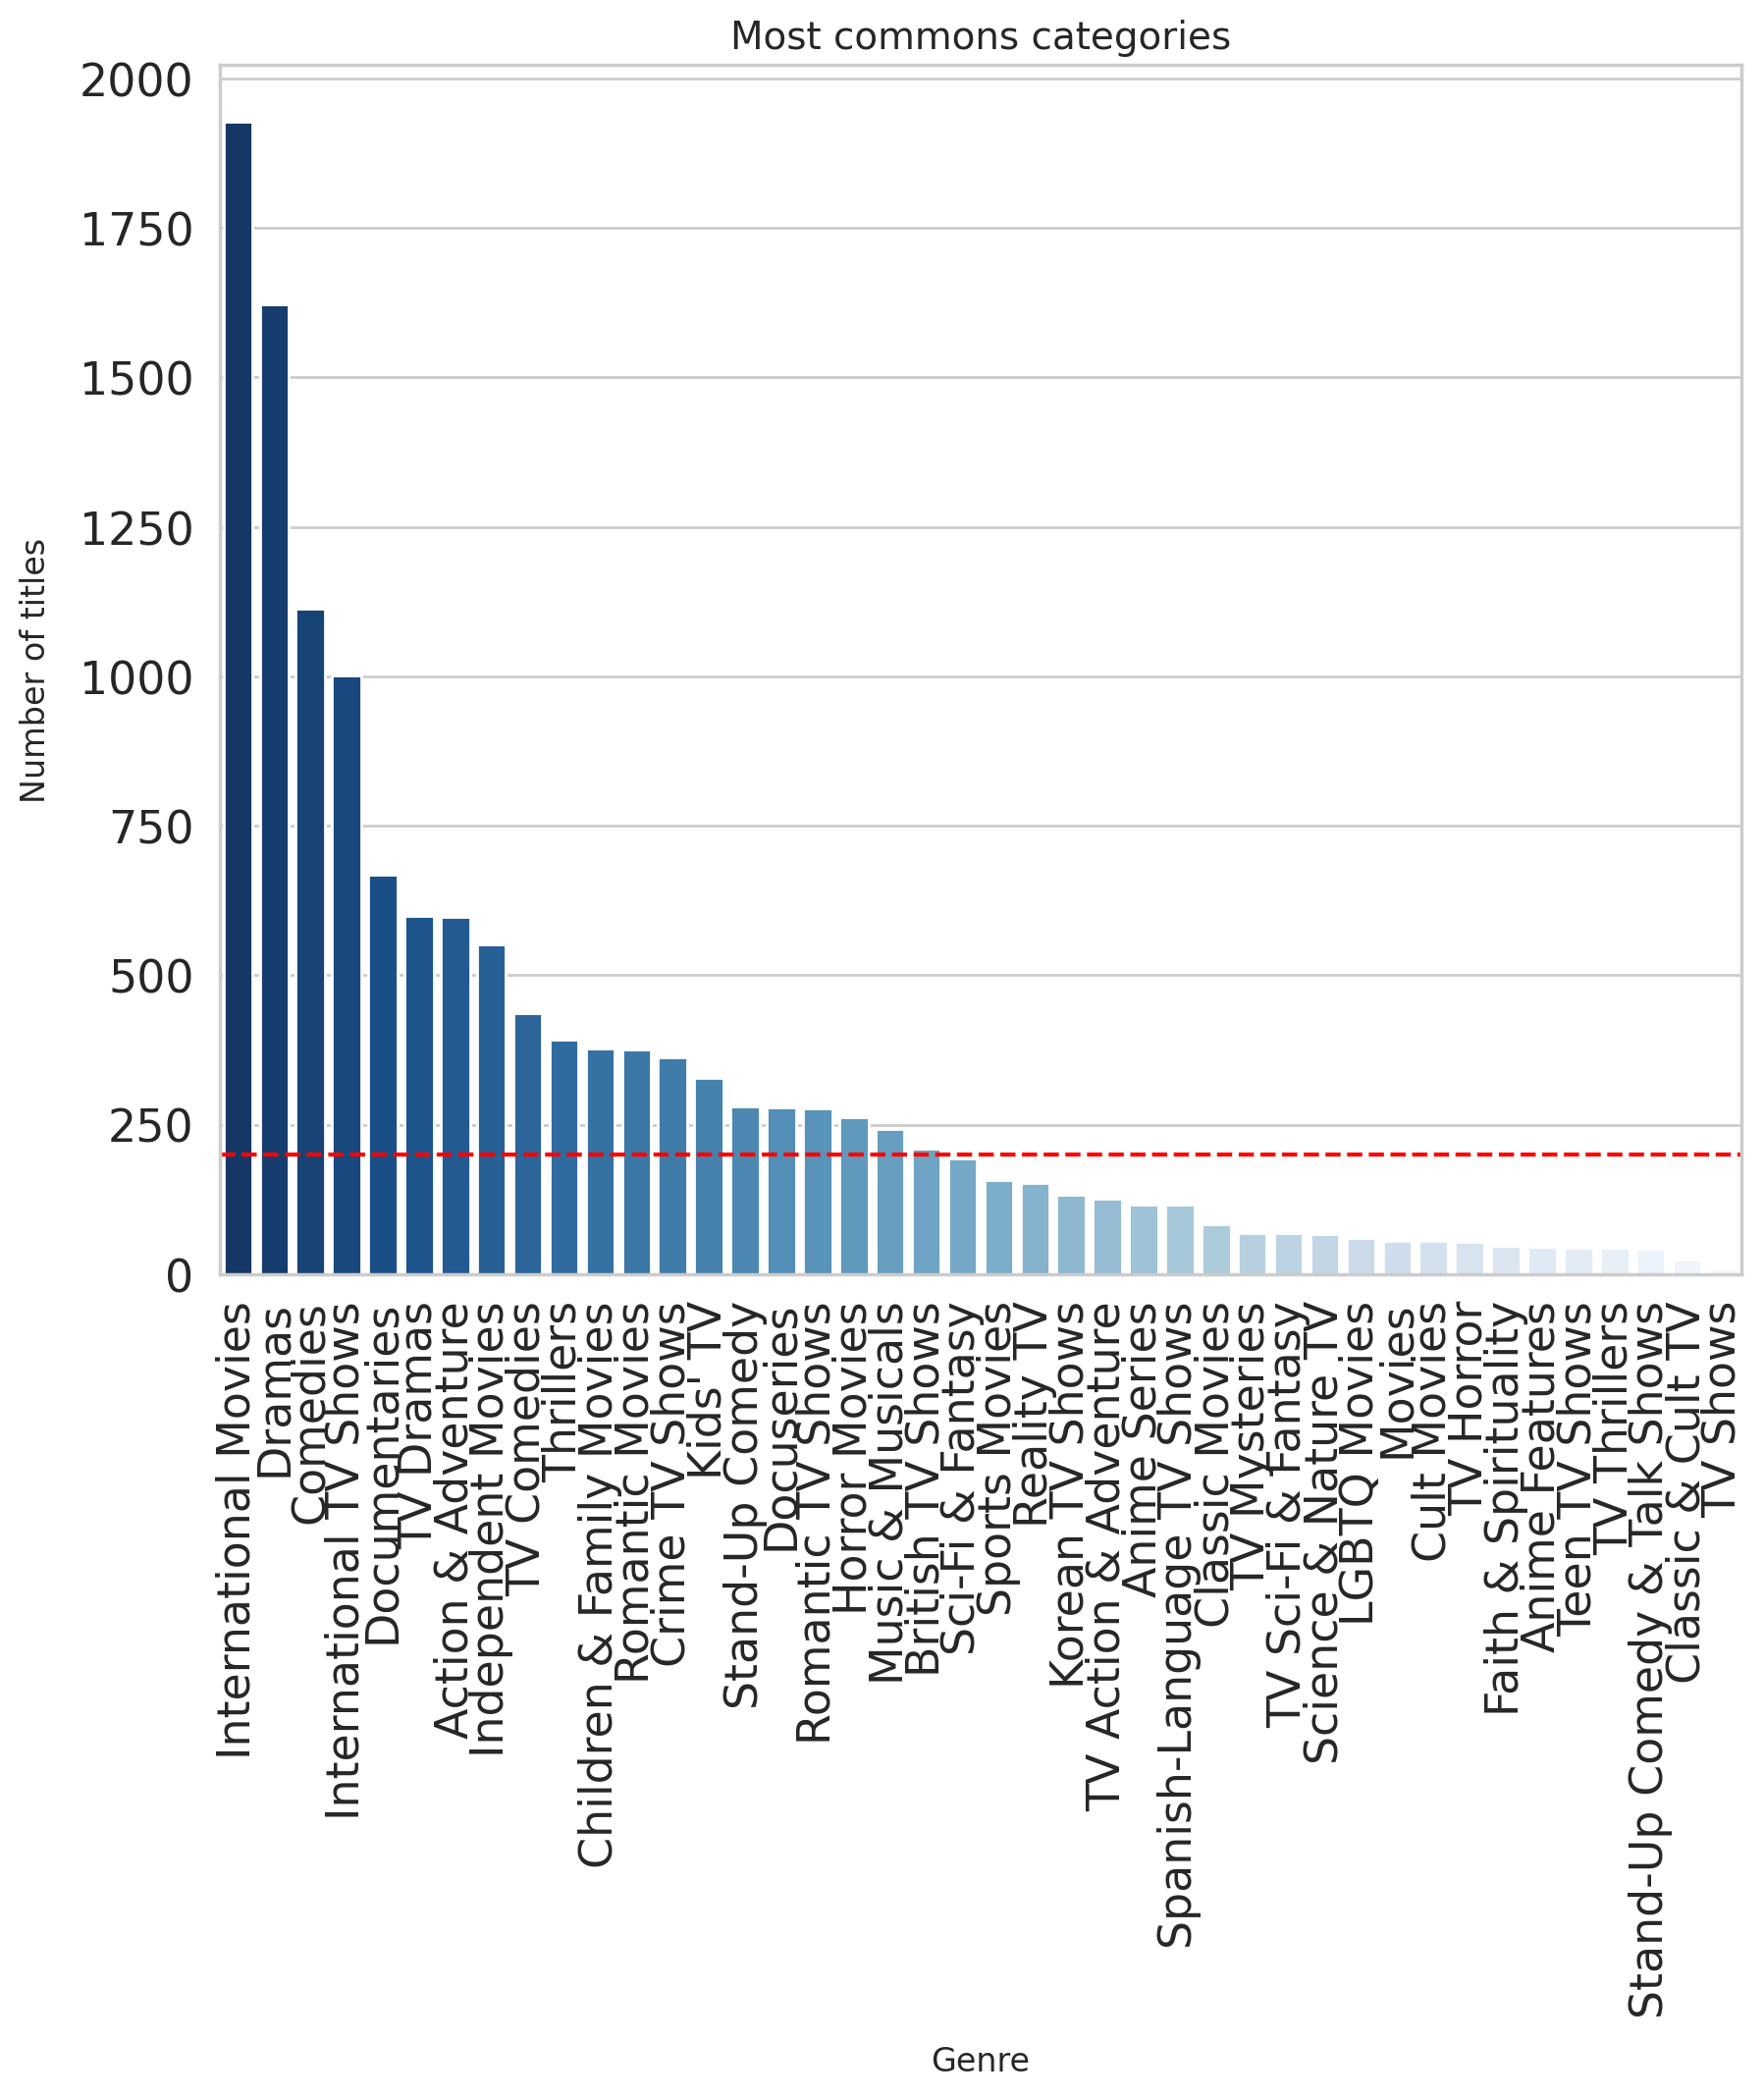

In [ ]:
plt.figure(figsize=(10,8))
sns.set(font_scale = 1.5)
sns.set_style('whitegrid')

threshold = 200

pal = sns.color_palette("Blues_r", len(bar_plot))
rank = bar_plot['count'].argsort().argsort()

sns.barplot(x='cat', y='count', data=bar_plot,
            hue='cat',
            palette=list(np.array(pal[::-1])[rank]),
            legend=False)
plt.axhline(threshold, ls='--', c='red')
plt.title("Most commons categories", fontsize=14)
plt.ylabel('Number of titles', fontsize=12)
plt.xlabel('Genre', fontsize=12)
plt.xticks(rotation='vertical')

plt.show()

In [ ]:
main_categories = pd.DataFrame()
main_categories = bar_plot[bar_plot['count']>200]
categories = main_categories['cat'].values
categories = np.append(categories,'Others')
not_category = []
description_category['Others'] = 0

for i in description_category.columns[1:]:
    if i not in categories:
        description_category.loc[description_category[i] == 1, 'Others'] = 1
        not_category.append(i)

description_category.drop(not_category, axis=1, inplace=True)

most_common_cat = pd.DataFrame()
most_common_cat['cat'] = description_category.columns[1:]
most_common_cat['count'] = description_category.iloc[:,1:].sum().values
most_common_cat.sort_values(['count'], inplace=True, ascending=False)
most_common_cat.reset_index(inplace=True, drop=True)
most_common_cat

,cat,count
0,International Movies,1927.0
1,Dramas,1623.0
2,Others,1574.0
3,Comedies,1113.0
4,International TV Shows,1001.0
5,Documentaries,668.0
6,TV Dramas,599.0
7,Action & Adventure,597.0
8,Independent Movies,552.0
9,TV Comedies,436.0


Counting the number of titles having multiple labels and calculating the word frequency can be helpful as well. We see most titles belong to three genres



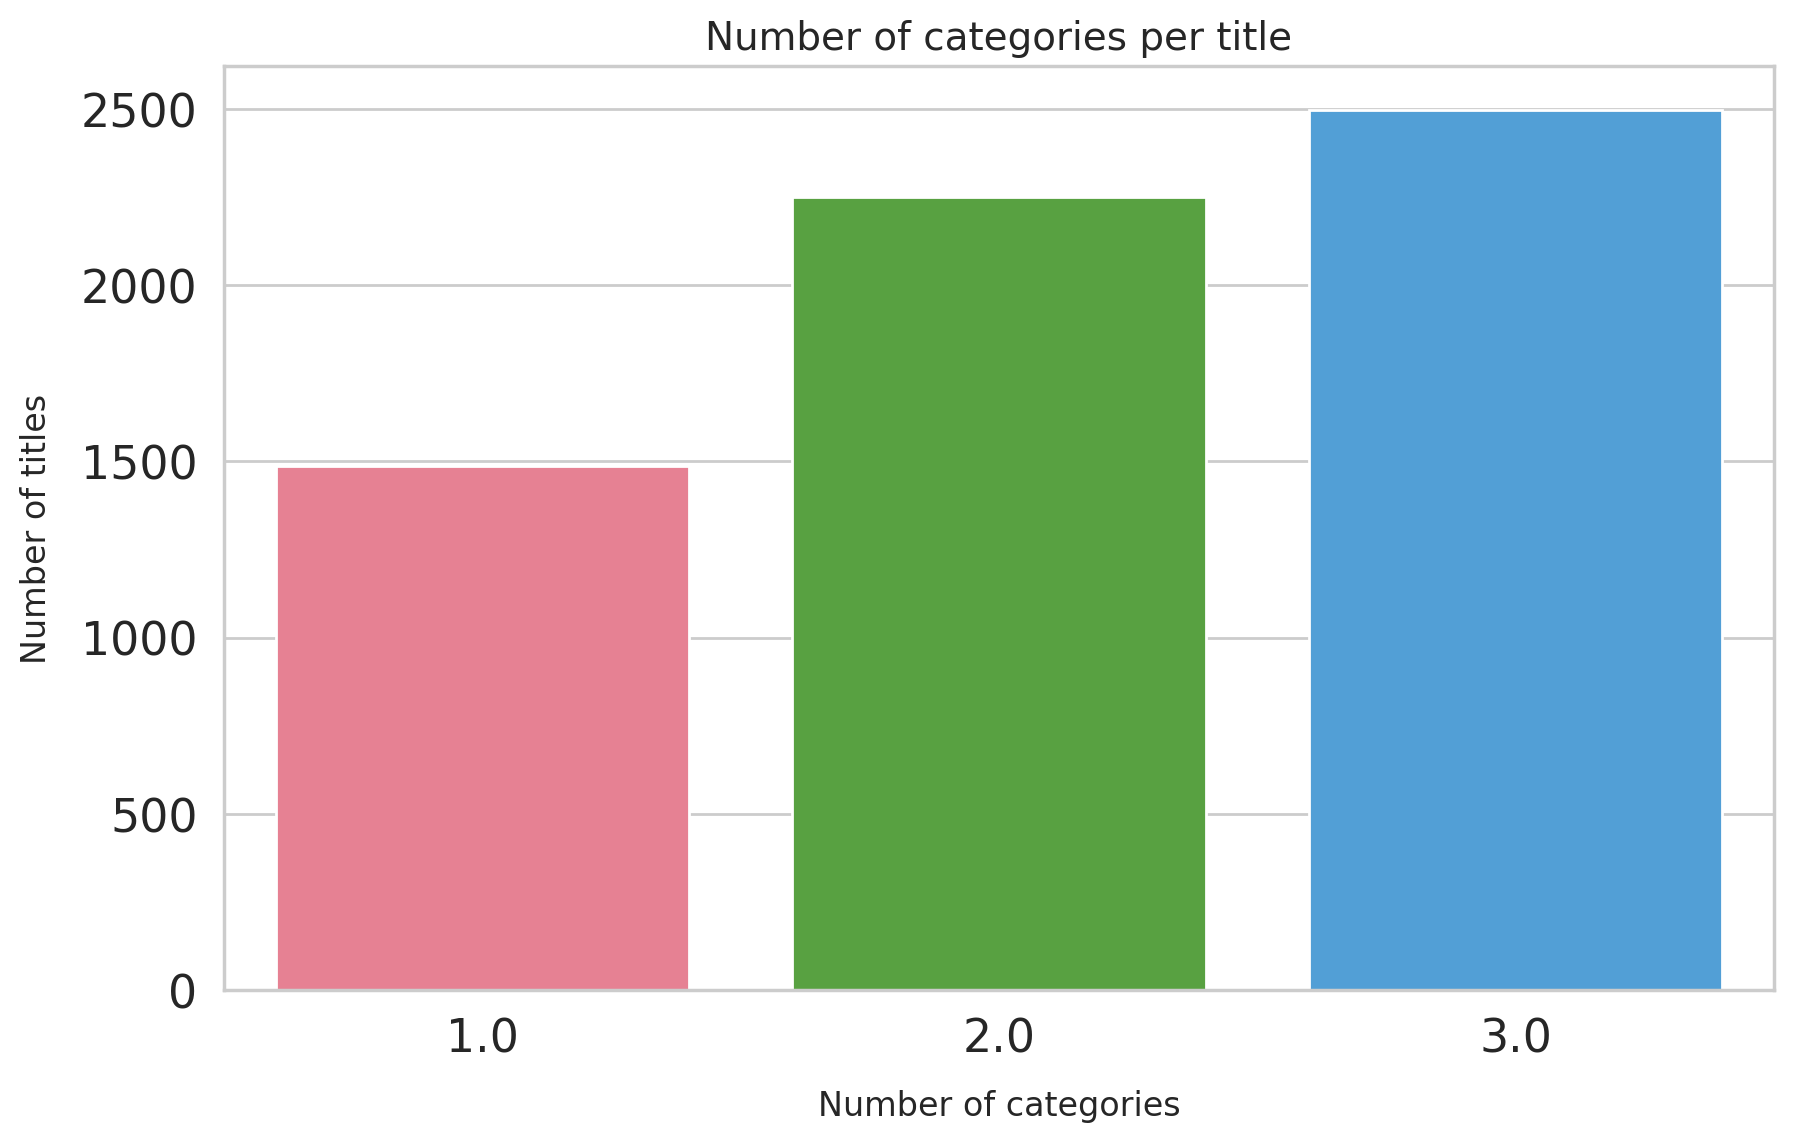

In [ ]:
sns.set(font_scale = 1.5)
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))

multiLabel_counts = description_category.iloc[:, 1:].sum(axis=1).value_counts()
num_bars = len(multiLabel_counts)
palette = sns.color_palette("husl", num_bars)  # Choose your desired color palette

sns.barplot(x=multiLabel_counts.index, y=multiLabel_counts.values,palette=palette,hue=multiLabel_counts.index,legend=False)
plt.title("Number of categories per title", fontsize=14)
plt.ylabel('Number of titles', fontsize=12)
plt.xlabel('Number of categories', fontsize=12)

plt.show()

### Text Analysis of Description

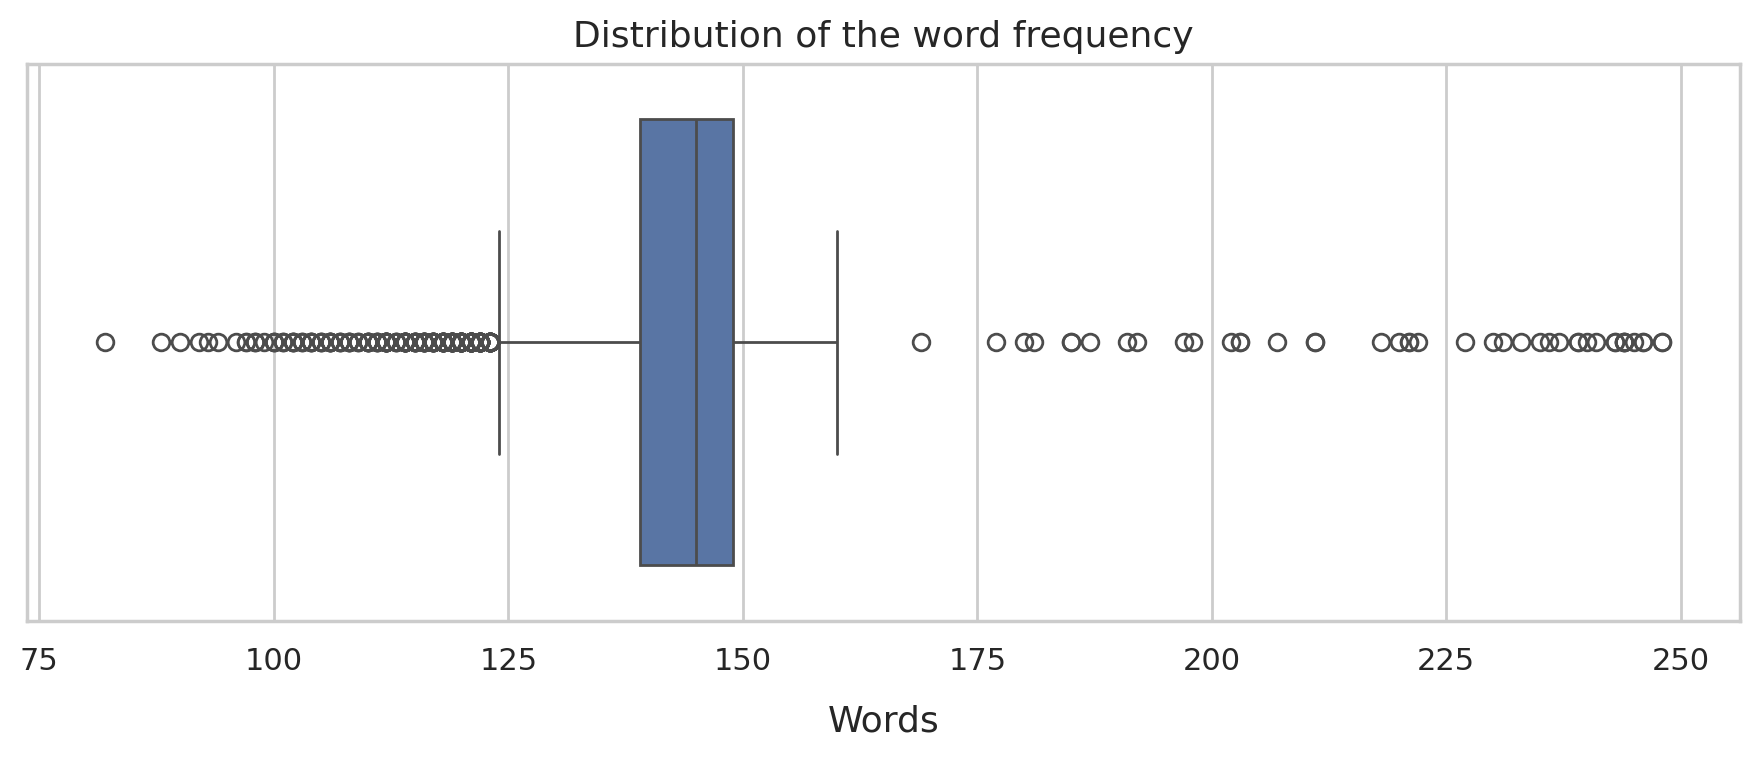

In [ ]:
boxplot = description_category.copy()
boxplot['len'] = description_category.description.apply(lambda x: len(x))
sns.set(style="whitegrid",rc={"font.size":13,"axes.labelsize":13})

plt.figure(figsize=(9, 4))

ax = sns.boxplot(x='len', data=boxplot, orient="h")
plt.ylabel('')
plt.xlabel('Words')
plt.title("Distribution of the word frequency", fontsize=13)
plt.tight_layout(h_pad=3)

Most titles belong to three genres, while the majority of the descriptions have about 150 words. The word cloud below shows the most frequent words in the description field.

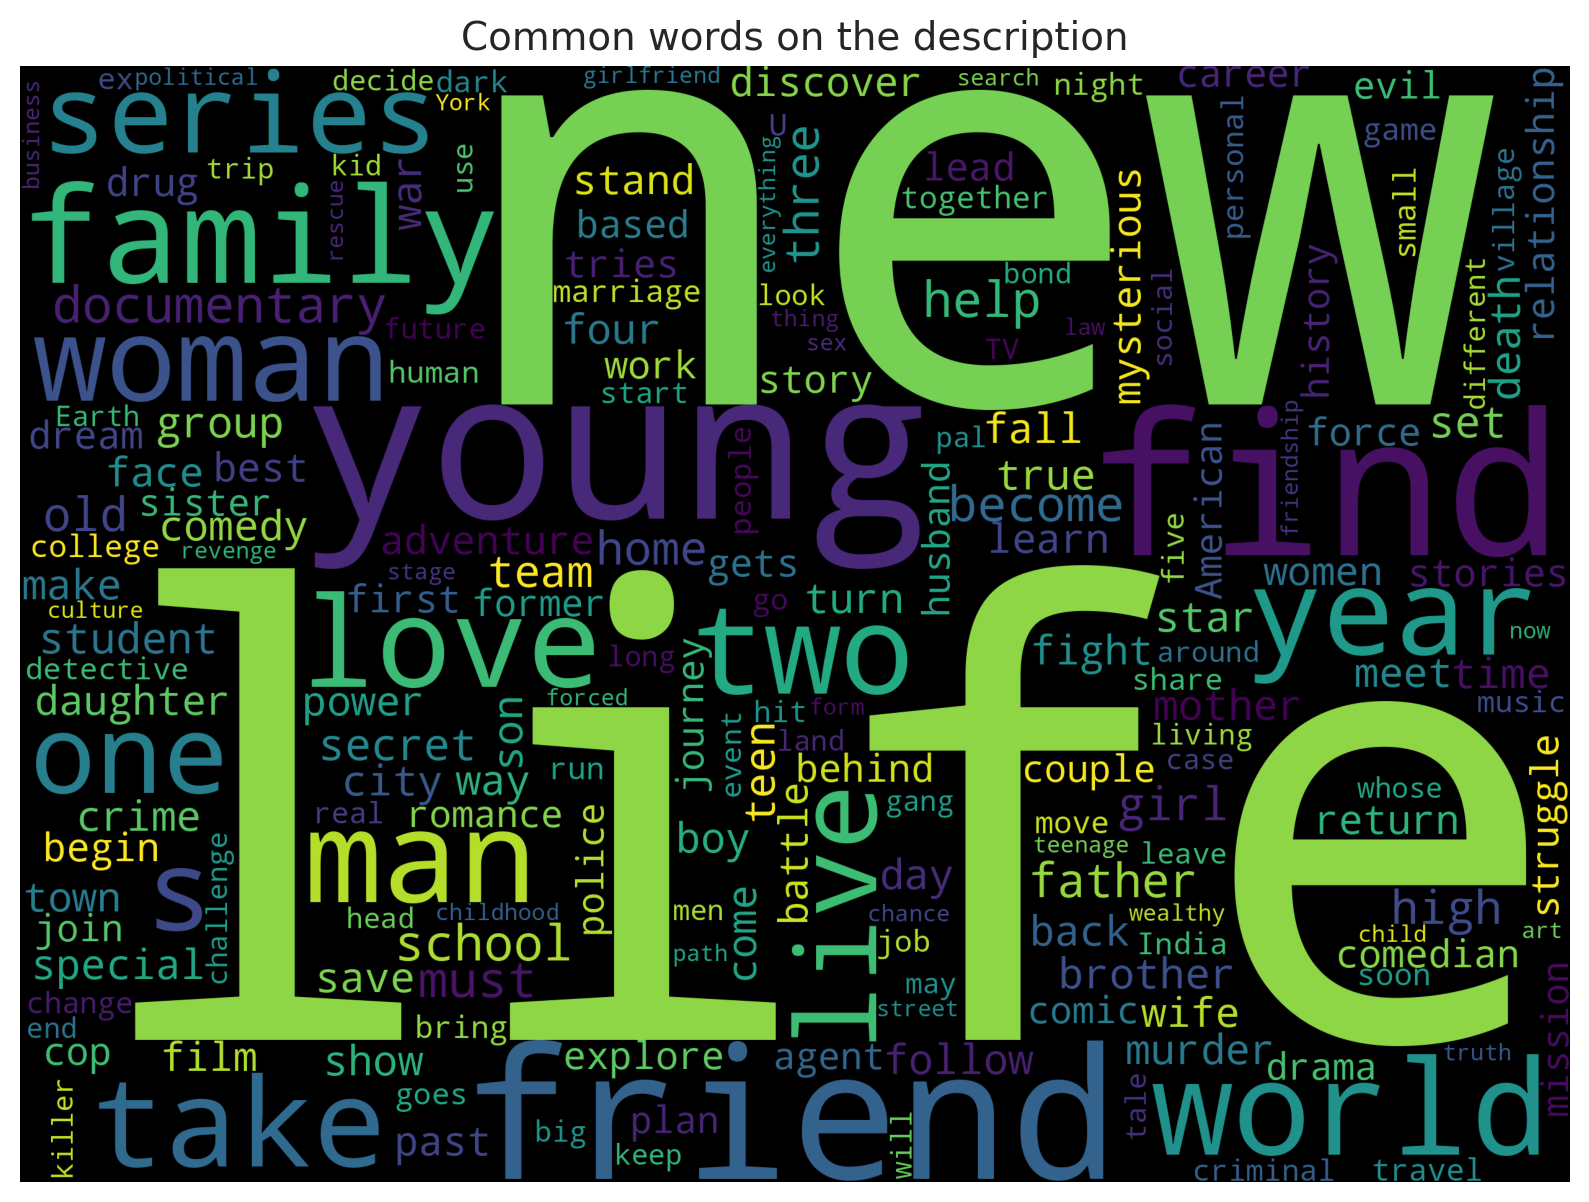

In [ ]:
from wordcloud import WordCloud,STOPWORDS

plt.figure(figsize=(10,20))
text = description_category.description.values
cloud = WordCloud(
                          stopwords=STOPWORDS,
                          background_color='black',
                          collocations=False,
                          width=2500,
                          height=1800
                         ).generate(" ".join(text))
plt.axis('off')
plt.title("Common words on the description",fontsize=14)
plt.imshow(cloud)

###Preprocessing

The following cell performs preprocessing of the Text

In [ ]:
import re
from nltk.stem.snowball import SnowballStemmer

def decontract(sentence):
    # specific
    sentence = re.sub(r"won't", "will not", sentence)
    sentence = re.sub(r"can\'t", "can not", sentence)

    # general
    sentence = re.sub(r"n\'t", " not", sentence)
    sentence = re.sub(r"\'re", " are", sentence)
    sentence = re.sub(r"\'s", " is", sentence)
    sentence = re.sub(r"\'d", " would", sentence)
    sentence = re.sub(r"\'ll", " will", sentence)
    sentence = re.sub(r"\'t", " not", sentence)
    sentence = re.sub(r"\'ve", " have", sentence)
    sentence = re.sub(r"\'m", " am", sentence)
    return sentence

def cleanPunc(sentence):
    cleaned = re.sub(r'[?|!|\'|"|#]',r'',sentence)
    cleaned = re.sub(r'[.|,|)|(|\|/]',r' ',cleaned)
    cleaned = cleaned.strip()
    cleaned = cleaned.replace("\n"," ")
    return cleaned

def keepAlpha(sentence):
    alpha_sent = ""
    for word in sentence.split():
        alpha_word = re.sub('[^a-z A-Z]+', '', word)
        alpha_sent += alpha_word
        alpha_sent += " "
    alpha_sent = alpha_sent.strip()
    return alpha_sent

def removeStopWords(sentence):
    global re_stop_words
    return re_stop_words.sub("", sentence)


stopwords= set(['br', 'the', 'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've",\
            "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', \
            'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their',\
            'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', \
            'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', \
            'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', \
            'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after',\
            'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further',\
            'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more',\
            'most', 'other', 'some', 'such', 'only', 'own', 'same', 'so', 'than', 'too', 'very', \
            's', 't', 'can', 'will', 'just', 'don', "don't", 'should', "should've", 'now', 'd', 'll', 'm', 'o', 're', \
            've', 'y', 'ain', 'aren', "aren't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn',\
            "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn',\
            "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", \
            'won', "won't", 'wouldn', "wouldn't"])

re_stop_words = re.compile(r"\b(" + "|".join(stopwords) + ")\\W", re.I)

stemmer = SnowballStemmer("english")
def stemming(sentence):
    stemSentence = ""
    for word in sentence.split():
        stem = stemmer.stem(word)
        stemSentence += stem
        stemSentence += " "
    stemSentence = stemSentence.strip()
    return stemSentence

description_category['description'] = description_category['description'].str.lower()
description_category['description'] = description_category['description'].apply(decontract)
description_category['description'] = description_category['description'].apply(cleanPunc)
description_category['description'] = description_category['description'].apply(keepAlpha)
description_category['description'] = description_category['description'].apply(removeStopWords)
description_category['description'] = description_category['description'].apply(stemming)

Train-Test Split and Vectorizing Text

In [ ]:
#Seed for Reproduction
seed =  43
X_train, X_test, y_train, y_test = train_test_split(description_category['description'],
                                                    description_category[description_category.columns[1:]],
                                                    test_size=0.3,
                                                    random_state=seed,shuffle=True)

In [ ]:
X_train

,description
3594,hire captur dead creatur terror south africa s...
1296,shopkin shoppi jet around world search miss fr...
3856,success advoc femal client difficult divorc ca...
565,jenni slate first standup special mix stage ti...
4316,honest though overzeal polic offic strive good...
...,...
6202,thirtysometh career woman jaeyeong attempt jug...
2325,casino du liban lebanes actor comedian adel ka...
2303,bigciti art dealer travel north carolina meet ...
3392,one move u two childhood friend promis reunit ...


### Traditional TF-IDF for Sentence Representation

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=9000,strip_accents='unicode', analyzer='word')
vectorizer.fit(X_train) # Fit only on Train

X_train_tfidf = vectorizer.transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

### Using FastText

In [ ]:
! pip install fasttext
! gdown https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.bin.gz
! gunzip '/content/cc.en.300.bin.gz'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 2.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached pybind11-2.13.6-py3-none-any.whl.metadata (9.5 kB)
Using cached pybind11-2.13.6-py3-none-any.whl (243 kB)
  Created wheel for fasttext: filename=fasttext-0.9.3-cp311-cp311-linux_x86_64.whl size=4313470 sha256=490fa238490fe11cd72c5eca0c93f7ff013ca368a6bba48b833571b71977dfb3
  Stored in directory: /root/.cache/pip/wheels/65/4f/35/5057db0249224e9ab55a513fa6b79451473ceb7713017823c3
Successfully built fasttext
Downloading...
From: https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.en.300.bin.gz
To: /content/cc.en.300.bin.gz
100% 4.50G/4.50G [00:18<00:00, 244MB/s]


In [ ]:
import fasttext
#Load Model
model = fasttext.load_model('/content/cc.en.300.bin')
def fasttext_series_to_embeddings(series):
    # Process all sentences
    embeddings = []
    for sentence in series:
        embeddings.append(model.get_sentence_vector(sentence))

    return np.array(embeddings)

In [ ]:
X_train_fasttext = fasttext_series_to_embeddings(X_train)
X_test_fasttext = fasttext_series_to_embeddings(X_test)

In [ ]:
X_train_fasttext.shape

(4363, 300)

### MLP Model

In [ ]:
from sklearn.neural_network import MLPClassifier
mlp=MLPClassifier(random_state=0, early_stopping=True, verbose=2)


mlp = MLPClassifier(
    hidden_layer_sizes=(64,32),  # Progressive layer shrinkage Start with larger layers (e.g., 256 units) and progressively reduce sizes (128 → 64) to force feature abstraction.
    activation='relu',                  # Standard for text tasks
    solver='adam',                      # Adaptive learning
    early_stopping=True,                # Prevent overfitting
    max_iter=500,                        # Ensure convergence
    random_state=42
)

###Use TFIDF and MLP

In [ ]:
X_train_tfidf.shape

(4363, 9000)

In [ ]:
from sklearn.multioutput import ClassifierChain
from sklearn.metrics import f1_score

classifier_chain = ClassifierChain(mlp)
classifier_chain .fit(X_train_tfidf, y_train)
predictions = classifier_chain.predict(X_test_tfidf)

print('F1 Score [ClassifierChain TFIDF-MLP] is {}'.format(f1_score(y_test, predictions, average='weighted')))


F1 Score [ClassifierChain TFIDF-MLP] is 0.32603514358280644


An F1 score ranges from 0 to 1, where 1 is perfect and 0 is the worst. A score of approximately 0.30 suggests that the model is performing somewhat better than random guessing but still has significant room for improvement.

In [ ]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import f1_score

classifier_multiout = MultiOutputClassifier(mlp)
classifier_multiout.fit(X_train_tfidf, y_train)
predictions = classifier_multiout.predict(X_test_tfidf)

print('F1 Score [MultiOutputClassifier TFIDF-MLP] is {}'.format(f1_score(y_test, predictions, average='weighted')))

F1 Score [MultiOutputClassifier TFIDF-MLP] is 0.2210552534345637


###Use FastText with MLP

In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(200,100,50,25),  # Progressive layer shrinkage Start with larger layers (e.g., 256 units) and progressively reduce sizes (128 → 64) to force feature abstraction.
    activation='relu',                  # Standard for text tasks
    solver='adam',                      # Adaptive learning
    early_stopping=True,                # Prevent overfitting
    max_iter=500,                        # Ensure convergence
    random_state=42
)

In [ ]:
from sklearn.multioutput import ClassifierChain
from sklearn.metrics import f1_score

classifier_chain = ClassifierChain(mlp)
classifier_chain .fit(X_train_fasttext, y_train)
predictions = classifier_chain .predict(X_test_fasttext)

print('F1 Score [ClassifierChain FastText-MLP] is {}'.format(f1_score(y_test, predictions, average='weighted')))


F1 Score [ClassifierChain FastText-MLP] is 0.34241185607438507


In [ ]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import f1_score

classifier_multiout = MultiOutputClassifier(mlp)
classifier_multiout.fit(X_train_fasttext, y_train)
predictions = classifier_multiout.predict(X_test_fasttext)

print('F1 Score [MultiOutputClassifier FastText-MLP] is {}'.format(f1_score(y_test, predictions, average='weighted')))

F1 Score [MultiOutputClassifier FastText-MLP] is 0.26111962221010426


In [ ]:
mlp.fit(X_train_fasttext, y_train)
predictions = mlp.predict(X_test_fasttext)
print('F1 Score FastText-MLP is {}'.format(f1_score(y_test, predictions, average='weighted')))

F1 Score FastText-MLP is 0.0548026286770825
